# 📊 MODEL 1: RIDE OUTCOME PREDICTION (MULTI-CLASS CLASSIFICATION)
##This model predicts whether a booking will be Completed, Cancelled, or Incomplete before the trip starts. It analyzes customer behavior, driver reliability, time patterns, location data, and contextual factors to forecast the final booking outcome. This helps Rapido proactively manage operational risks and reduce cancellations by 20%.


In [1]:

from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')

# Check for engineered dataset
file_path = '/content/drive/MyDrive/Rapido_Project/data/final/master_dataset_engineered.csv'

if os.path.exists(file_path):
    file_size = os.path.getsize(file_path) / (1024**2)
    print(f"✅ SUCCESS! Engineered dataset found!")
    print(f"📁 File: master_dataset_engineered.csv")
    print(f"💾 Size: {file_size:.2f} MB")
    print(f"📍 Location: {file_path}")
    print("\n🚀 You're ready for Notebook 3!")
else:
    print(f"❌ ERROR: Engineered dataset NOT found!")
    print(f"Expected location: {file_path}")
    print("\n⚠️ Please complete Notebook 2 first!")

Mounted at /content/drive
✅ SUCCESS! Engineered dataset found!
📁 File: master_dataset_engineered.csv
💾 Size: 83.79 MB
📍 Location: /content/drive/MyDrive/Rapido_Project/data/final/master_dataset_engineered.csv

🚀 You're ready for Notebook 3!


In [2]:
"""
Notebook 3: Model Training & Evaluation
Rapido ML Project - 4 Models as per PDF Requirements
"""

from google.colab import drive
import os
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
print("🔗 Mounting Google Drive...")
drive.mount('/content/drive')

# Define paths
BASE_PATH = '/content/drive/MyDrive/Rapido_Project/'
DATA_PATH = os.path.join(BASE_PATH, 'data/final/')
MODEL_PATH = os.path.join(BASE_PATH, 'models/')
VIZ_PATH = os.path.join(BASE_PATH, 'visualizations/')

# Create model folder if doesn't exist
os.makedirs(MODEL_PATH, exist_ok=True)

print("✅ Google Drive mounted!")
print(f"📂 Data path: {DATA_PATH}")
print(f"📂 Model path: {MODEL_PATH}")
print("="*70)

🔗 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!
📂 Data path: /content/drive/MyDrive/Rapido_Project/data/final/
📂 Model path: /content/drive/MyDrive/Rapido_Project/models/


In [3]:
"""
Cell 2: Import All Required Libraries for Modeling
"""

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Model saving
import pickle
import joblib

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Set plot style
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print("="*70)

✅ All libraries imported successfully!


In [4]:
"""
Cell 3: Load the Engineered Dataset from Notebook 2
"""

print("📥 LOADING ENGINEERED DATASET")
print("="*70)

# Load dataset
dataset_path = os.path.join(DATA_PATH, 'master_dataset_engineered.csv')

try:
    df = pd.read_csv(dataset_path)

    print(f"✅ Dataset loaded successfully!")
    print(f"\n📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"💾 Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Check for target variables
    target_vars = [col for col in df.columns if col.startswith('target_')]

    print(f"\n🎯 Target Variables Found ({len(target_vars)}):")
    for target in target_vars:
        print(f"   • {target}")

    # Check data quality
    missing_total = df.isnull().sum().sum()
    missing_pct = (missing_total / df.size) * 100

    print(f"\n📊 Data Quality:")
    print(f"   Missing values: {missing_total:,} ({missing_pct:.2f}%)")
    print(f"   Duplicates: {df.duplicated().sum():,}")

    print("\n✅ Dataset ready for modeling!")

except FileNotFoundError:
    print(f"❌ ERROR: Dataset not found at {dataset_path}")
    print("⚠️ Please ensure Notebook 2 completed successfully!")
    raise

print("="*70)

📥 LOADING ENGINEERED DATASET
✅ Dataset loaded successfully!

📊 Dataset Shape: 100,000 rows × 152 columns
💾 Memory Usage: 282.27 MB

🎯 Target Variables Found (3):
   • target_outcome
   • target_outcome_encoded
   • target_is_cancelled

📊 Data Quality:
   Missing values: 390,243 (2.57%)
   Duplicates: 0

✅ Dataset ready for modeling!


In [5]:
"""
Cell 4: Handle Missing Values and Prepare Data (ENHANCED)
"""

print("🔧 HANDLING MISSING VALUES")
print("="*70)

# Store original shape
original_shape = df.shape

# Check missing values by column
missing_by_col = df.isnull().sum()
cols_with_missing = missing_by_col[missing_by_col > 0].sort_values(ascending=False)

if len(cols_with_missing) > 0:
    print(f"\n📊 Columns with missing values ({len(cols_with_missing)}):")
    print("\nTop 20:")
    for col, count in cols_with_missing.head(20).items():
        pct = (count / len(df)) * 100
        print(f"   {col:40s}: {count:6,} ({pct:5.2f}%)")

    if len(cols_with_missing) > 20:
        print(f"   ... and {len(cols_with_missing) - 20} more columns")

    # Strategy for handling missing values
    print(f"\n🔧 Applying missing value strategies...")

    # For numerical columns: fill with median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            # If median is also NaN, use 0
            if pd.isna(median_val):
                df[col].fillna(0, inplace=True)
            else:
                df[col].fillna(median_val, inplace=True)

    # For categorical columns: fill with mode or 'Unknown'
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown'
            df[col].fillna(mode_val, inplace=True)

    # Verify
    remaining_missing = df.isnull().sum().sum()
    print(f"\n✅ Missing values handled!")
    print(f"   Before: {missing_by_col.sum():,} missing values")
    print(f"   After: {remaining_missing:,} missing values")

    if remaining_missing > 0:
        print(f"\n⚠️ Still {remaining_missing} missing values found!")
        print("   Replacing all remaining NaN with 0...")
        df.fillna(0, inplace=True)
        print(f"   ✅ All NaN values replaced!")

else:
    print("\n✅ No missing values found!")

# Replace any infinite values
print(f"\n🔍 Checking for infinite values...")
inf_count = 0
for col in df.select_dtypes(include=[np.number]).columns:
    if np.isinf(df[col]).any():
        inf_in_col = np.isinf(df[col]).sum()
        print(f"   ⚠️ {col}: {inf_in_col} infinite values")
        df[col].replace([np.inf, -np.inf], np.nan, inplace=True)
        df[col].fillna(df[col].median(), inplace=True)
        inf_count += inf_in_col

if inf_count > 0:
    print(f"   ✅ Replaced {inf_count} infinite values")
else:
    print(f"   ✅ No infinite values found")

# Final verification
final_missing = df.isnull().sum().sum()
print(f"\n📊 FINAL VERIFICATION:")
print(f"   Total missing values: {final_missing}")
print(f"   Total infinite values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")

if final_missing == 0:
    print(f"   ✅ Dataset is clean and ready!")
else:
    print(f"   ⚠️ WARNING: Still have missing values - forcing cleanup...")
    df.fillna(0, inplace=True)
    print(f"   ✅ Forced all NaN to 0")

# Check final shape
print(f"\n📊 Final Dataset Shape: {df.shape}")

print("="*70)

🔧 HANDLING MISSING VALUES

📊 Columns with missing values (5):

Top 20:
   day_of_week                             : 100,000 (100.00%)
   day_name                                : 100,000 (100.00%)
   incomplete_ride_reason                  : 91,630 (91.63%)
   rush_hour_type                          : 66,959 (66.96%)
   actual_ride_time_min                    : 31,654 (31.65%)

🔧 Applying missing value strategies...

✅ Missing values handled!
   Before: 390,243 missing values
   After: 0 missing values

🔍 Checking for infinite values...
   ✅ No infinite values found

📊 FINAL VERIFICATION:
   Total missing values: 0
   Total infinite values: 0
   ✅ Dataset is clean and ready!

📊 Final Dataset Shape: (100000, 152)


In [6]:
"""
Cell 4.5: Deep Data Quality Check Before Modeling
"""

print("🔍 DEEP DATA QUALITY CHECK")
print("="*70)

# Check for NaN in entire dataset
total_nan = df.isnull().sum().sum()
print(f"\n📊 Overall NaN count: {total_nan}")

if total_nan > 0:
    print(f"   ⚠️ Found {total_nan} NaN values!")
    print("\n   Columns with NaN:")
    nan_cols = df.columns[df.isnull().any()].tolist()
    for col in nan_cols[:20]:  # Show first 20
        nan_count = df[col].isnull().sum()
        print(f"      {col}: {nan_count}")

    print("\n   🔧 Forcing cleanup...")
    df.fillna(0, inplace=True)
    print(f"   ✅ All NaN replaced with 0")

# Check for infinite values
inf_check = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"\n📊 Overall Inf count: {inf_check}")

if inf_check > 0:
    print(f"   ⚠️ Found {inf_check} infinite values!")
    for col in df.select_dtypes(include=[np.number]).columns:
        if np.isinf(df[col]).any():
            df[col].replace([np.inf, -np.inf], 0, inplace=True)
    print(f"   ✅ All Inf replaced with 0")

# Check for object columns that should be numeric
print(f"\n📊 Data Types:")
print(f"   Numeric columns: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"   Object columns: {len(df.select_dtypes(include=['object']).columns)}")

# Final sanity check
print(f"\n✅ FINAL STATUS:")
print(f"   Total NaN: {df.isnull().sum().sum()}")
print(f"   Total Inf: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"   Dataset shape: {df.shape}")

assert df.isnull().sum().sum() == 0, "❌ ERROR: Still have NaN values!"
assert np.isinf(df.select_dtypes(include=[np.number])).sum().sum() == 0, "❌ ERROR: Still have Inf values!"

print(f"\n🎉 Dataset is 100% clean and ready for modeling!")
print("="*70)

🔍 DEEP DATA QUALITY CHECK

📊 Overall NaN count: 0

📊 Overall Inf count: 0

📊 Data Types:
   Numeric columns: 116
   Object columns: 36

✅ FINAL STATUS:
   Total NaN: 0
   Total Inf: 0
   Dataset shape: (100000, 152)

🎉 Dataset is 100% clean and ready for modeling!


In [7]:
"""
Cell 5: Prepare Features for Modeling
"""

print("🎯 PREPARING FEATURES FOR MODELING")
print("="*70)

# Identify target variables (as per PDF requirements)
targets = {
    'ride_outcome': 'target_outcome_encoded',  # Multi-class
    'fare': 'target_fare',  # Regression
    'customer_cancel': 'target_is_cancelled',  # Binary
    'driver_delay': 'target_driver_delayed' if 'target_driver_delayed' in df.columns else 'is_delayed'  # Binary
}

print("\n🎯 Target Variables:")
for model_name, target_col in targets.items():
    if target_col in df.columns:
        print(f"   ✅ {model_name:20s}: {target_col}")
    else:
        print(f"   ⚠️ {model_name:20s}: {target_col} NOT FOUND")

# Identify feature columns (exclude targets, IDs, and original status)
exclude_cols = [
    'booking_id', 'customer_id', 'driver_id',
    'booking_status', 'booking_outcome',
    'target_outcome', 'target_outcome_encoded',
    'target_fare', 'target_is_cancelled',
    'target_customer_cancelled', 'target_driver_delayed',
    'booking_date', 'booking_time', 'booking_datetime'
]

# Get all columns
all_cols = df.columns.tolist()

# Remove exclude columns
feature_cols = [col for col in all_cols if col not in exclude_cols]

# Remove any remaining datetime columns
feature_cols = [col for col in feature_cols
                if not pd.api.types.is_datetime64_any_dtype(df[col])]

print(f"\n📋 Feature Engineering Summary:")
print(f"   Total columns: {len(all_cols)}")
print(f"   Target columns: {len(exclude_cols)}")
print(f"   Feature columns: {len(feature_cols)}")

# Separate numeric and categorical features
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df[feature_cols].select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 Feature Types:")
print(f"   Numeric features: {len(numeric_features)}")
print(f"   Categorical features: {len(categorical_features)}")

# Show sample features
print(f"\n📋 Sample Numeric Features (first 10):")
for feat in numeric_features[:10]:
    print(f"   • {feat}")

if len(categorical_features) > 0:
    print(f"\n📋 Categorical Features ({len(categorical_features)}):")
    for feat in categorical_features[:10]:
        print(f"   • {feat}")
    if len(categorical_features) > 10:
        print(f"   ... and {len(categorical_features) - 10} more")

# Store for later use
print("\n💾 Storing feature lists for modeling...")

print("\n✅ Feature preparation complete!")
print("="*70)

🎯 PREPARING FEATURES FOR MODELING

🎯 Target Variables:
   ✅ ride_outcome        : target_outcome_encoded
   ⚠️ fare                : target_fare NOT FOUND
   ✅ customer_cancel     : target_is_cancelled
   ⚠️ driver_delay        : is_delayed NOT FOUND

📋 Feature Engineering Summary:
   Total columns: 152
   Target columns: 14
   Feature columns: 143

📊 Feature Types:
   Numeric features: 114
   Categorical features: 29

📋 Sample Numeric Features (first 10):
   • day_of_week
   • is_weekend
   • hour_of_day
   • ride_distance_km
   • base_fare
   • surge_multiplier
   • booking_value
   • cust_customer_age
   • cust_customer_signup_days_ago
   • cust_total_bookings

📋 Categorical Features (29):
   • city
   • pickup_location
   • drop_location
   • vehicle_type
   • estimated_ride_time_min
   • actual_ride_time_min
   • traffic_level
   • weather_condition
   • incomplete_ride_reason
   • cust_customer_gender
   ... and 19 more

💾 Storing feature lists for modeling...

✅ Feature preparat

In [8]:
"""
Cell 6: Prepare Data for Model 1 - Ride Outcome Prediction (ENHANCED)
Target: Completed / Cancelled / Incomplete (Multi-class Classification)
"""

print("="*70)
print("MODEL 1: RIDE OUTCOME PREDICTION (MULTI-CLASS CLASSIFICATION)")
print("="*70)

# Check if target exists
target_col = 'target_outcome_encoded'

if target_col not in df.columns:
    print(f"❌ ERROR: {target_col} not found!")
    print("Available target columns:", [col for col in df.columns if 'target' in col])
else:
    print(f"\n🎯 Target Variable: {target_col}")

    # Check class distribution
    print(f"\n📊 Class Distribution:")
    class_dist = df[target_col].value_counts().sort_index()

    # Get class names if available
    if 'target_outcome' in df.columns:
        class_mapping = df.groupby(target_col)['target_outcome'].first().to_dict()
        print(f"   Class Mapping: {class_mapping}")

    for cls, count in class_dist.items():
        pct = (count / len(df)) * 100
        print(f"   Class {cls}: {count:,} ({pct:.2f}%)")

    # Check for class imbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    print(f"\n⚖️ Imbalance Ratio: {imbalance_ratio:.2f}:1")

    if imbalance_ratio > 3:
        print(f"   ⚠️ MODERATE IMBALANCE - Will use class weights")
    elif imbalance_ratio > 10:
        print(f"   ⚠️ SEVERE IMBALANCE - Will use SMOTE + class weights")
    else:
        print(f"   ✅ BALANCED - No special handling needed")

    # Prepare features - Encode categorical variables
    print(f"\n🔧 Preparing features...")

    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # SAFETY CHECK: Remove any NaN from target
    if y.isnull().sum() > 0:
        print(f"   ⚠️ Found {y.isnull().sum()} NaN in target variable!")
        nan_indices = y[y.isnull()].index
        X = X.drop(nan_indices)
        y = y.drop(nan_indices)
        print(f"   ✅ Removed rows with NaN in target")

    # Encode categorical features
    label_encoders = {}

    print(f"\n🔧 Encoding categorical variables...")
    for col in categorical_features:
        if col in X.columns:
            le = LabelEncoder()
            # Handle any NaN in categorical before encoding
            X[col] = X[col].fillna('Unknown')
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le

    print(f"   ✅ Encoded {len(label_encoders)} categorical features")

    # Check for any remaining non-numeric columns
    non_numeric = X.select_dtypes(exclude=[np.number]).columns
    if len(non_numeric) > 0:
        print(f"   ⚠️ Dropping {len(non_numeric)} non-numeric columns: {list(non_numeric)}")
        X = X.select_dtypes(include=[np.number])

    # CRITICAL: Final NaN check before modeling
    print(f"\n🔍 FINAL DATA QUALITY CHECK:")
    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")
    print(f"   X NaN count: {X.isnull().sum().sum()}")
    print(f"   y NaN count: {y.isnull().sum()}")
    print(f"   X Inf count: {np.isinf(X).sum().sum()}")

    if X.isnull().sum().sum() > 0:
        print(f"\n   ⚠️ WARNING: Found NaN in features! Cleaning...")
        X = X.fillna(0)
        print(f"   ✅ Replaced all NaN with 0")

    if np.isinf(X).sum().sum() > 0:
        print(f"\n   ⚠️ WARNING: Found Inf in features! Cleaning...")
        X = X.replace([np.inf, -np.inf], 0)
        print(f"   ✅ Replaced all Inf with 0")

    # Verify clean
    assert X.isnull().sum().sum() == 0, "❌ Features still contain NaN!"
    assert y.isnull().sum() == 0, "❌ Target still contains NaN!"
    assert np.isinf(X).sum().sum() == 0, "❌ Features still contain Inf!"

    print(f"\n   ✅ Data is clean and ready!")

    # Final feature set
    print(f"\n📋 Final Feature Set:")
    print(f"   Features: {X.shape[1]}")
    print(f"   Samples: {X.shape[0]:,}")
    print(f"   Target classes: {y.nunique()}")

    # Train-test split (80/20 as per PDF)
    print(f"\n✂️ Splitting data (80/20)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"   Training set: {X_train.shape[0]:,} samples")
    print(f"   Test set: {X_test.shape[0]:,} samples")

    # Check class distribution in train/test
    print(f"\n   Training set distribution:")
    for cls, count in y_train.value_counts().sort_index().items():
        pct = (count / len(y_train)) * 100
        print(f"      Class {cls}: {count:,} ({pct:.2f}%)")

    print(f"\n   Test set distribution:")
    for cls, count in y_test.value_counts().sort_index().items():
        pct = (count / len(y_test)) * 100
        print(f"      Class {cls}: {count:,} ({pct:.2f}%)")

    # Scale features
    print(f"\n📏 Scaling features...")
    scaler_m1 = StandardScaler()
    X_train_scaled = scaler_m1.fit_transform(X_train)
    X_test_scaled = scaler_m1.transform(X_test)

    print(f"   ✅ Features scaled using StandardScaler")

    # Final verification after scaling
    print(f"\n🔍 POST-SCALING VERIFICATION:")
    print(f"   X_train_scaled NaN: {np.isnan(X_train_scaled).sum()}")
    print(f"   X_test_scaled NaN: {np.isnan(X_test_scaled).sum()}")
    print(f"   X_train_scaled Inf: {np.isinf(X_train_scaled).sum()}")
    print(f"   X_test_scaled Inf: {np.isinf(X_test_scaled).sum()}")

    if np.isnan(X_train_scaled).sum() > 0 or np.isnan(X_test_scaled).sum() > 0:
        print(f"   ⚠️ NaN detected after scaling! Replacing...")
        X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        print(f"   ✅ NaN/Inf cleaned")

    print(f"\n✅ Data preparation complete for Model 1!")

print("="*70)

MODEL 1: RIDE OUTCOME PREDICTION (MULTI-CLASS CLASSIFICATION)

🎯 Target Variable: target_outcome_encoded

📊 Class Distribution:
   Class Mapping: {0: 'Cancelled', 1: 'Completed'}
   Class 0: 23,284 (23.28%)
   Class 1: 76,716 (76.72%)

⚖️ Imbalance Ratio: 3.29:1
   ⚠️ MODERATE IMBALANCE - Will use class weights

🔧 Preparing features...

🔧 Encoding categorical variables...
   ✅ Encoded 29 categorical features

🔍 FINAL DATA QUALITY CHECK:
   X shape: (100000, 143)
   y shape: (100000,)
   X NaN count: 0
   y NaN count: 0
   X Inf count: 0

   ✅ Data is clean and ready!

📋 Final Feature Set:
   Features: 143
   Samples: 100,000
   Target classes: 2

✂️ Splitting data (80/20)...
   Training set: 80,000 samples
   Test set: 20,000 samples

   Training set distribution:
      Class 0: 18,627 (23.28%)
      Class 1: 61,373 (76.72%)

   Test set distribution:
      Class 0: 4,657 (23.29%)
      Class 1: 15,343 (76.72%)

📏 Scaling features...
   ✅ Features scaled using StandardScaler

🔍 POST-SC


🤖 MODEL 1.1: LOGISTIC REGRESSION

🔧 Training Logistic Regression...
   ✅ Training completed in 4.26 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.7295 (72.95%)
Precision (weighted): 0.7990
Recall (weighted): 0.7295
F1-Score (weighted): 0.7479
AUC: Could not calculate (requires ≥2 classes)

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.45      0.75      0.56      4657
           1       0.90      0.72      0.80     15343

    accuracy                           0.73     20000
   macro avg       0.68      0.74      0.68     20000
weighted avg       0.80      0.73      0.75     20000


🔍 CONFUSION MATRIX:
[[ 3485  1172]
 [ 4239 11104]]


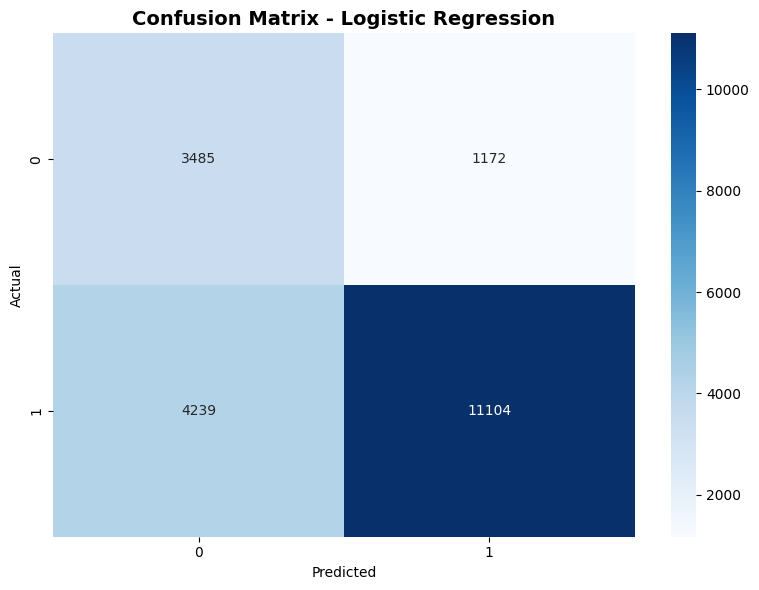


💾 Confusion matrix saved!


In [9]:
"""
Cell 7: Model 1.1 - Logistic Regression (Baseline)
"""

print("\n🤖 MODEL 1.1: LOGISTIC REGRESSION")
print("="*70)

from sklearn.linear_model import LogisticRegression
import time

# Train Logistic Regression
print("\n🔧 Training Logistic Regression...")

start_time = time.time()

# Using class_weight='balanced' to handle imbalance
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")

# Precision, Recall, F1 (weighted for multi-class)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"Precision (weighted): {precision_lr:.4f}")
print(f"Recall (weighted): {recall_lr:.4f}")
print(f"F1-Score (weighted): {f1_lr:.4f}")

# AUC (using One-vs-Rest approach)
try:
    auc_lr = roc_auc_score(y_test, y_pred_proba_lr, multi_class='ovr', average='weighted')
    print(f"AUC (weighted): {auc_lr:.4f}")
except:
    print(f"AUC: Could not calculate (requires ≥2 classes)")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test, y_pred_lr, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model1_lr_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model1_results = {
    'Logistic Regression': {
        'model': lr_model,
        'accuracy': accuracy_lr,
        'precision': precision_lr,
        'recall': recall_lr,
        'f1': f1_lr,
        'auc': auc_lr if 'auc_lr' in locals() else None,
        'training_time': training_time,
        'predictions': y_pred_lr
    }
}

print("="*70)


🌲 MODEL 1.2: RANDOM FOREST CLASSIFIER

🔧 Training Random Forest...
   ✅ Training completed in 36.22 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.9337 (93.38%)
Precision (weighted): 0.9329
Recall (weighted): 0.9337
F1-Score (weighted): 0.9331
AUC: Could not calculate

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4657
           1       0.95      0.96      0.96     15343

    accuracy                           0.93     20000
   macro avg       0.91      0.90      0.91     20000
weighted avg       0.93      0.93      0.93     20000


🔍 CONFUSION MATRIX:
[[ 3870   787]
 [  538 14805]]


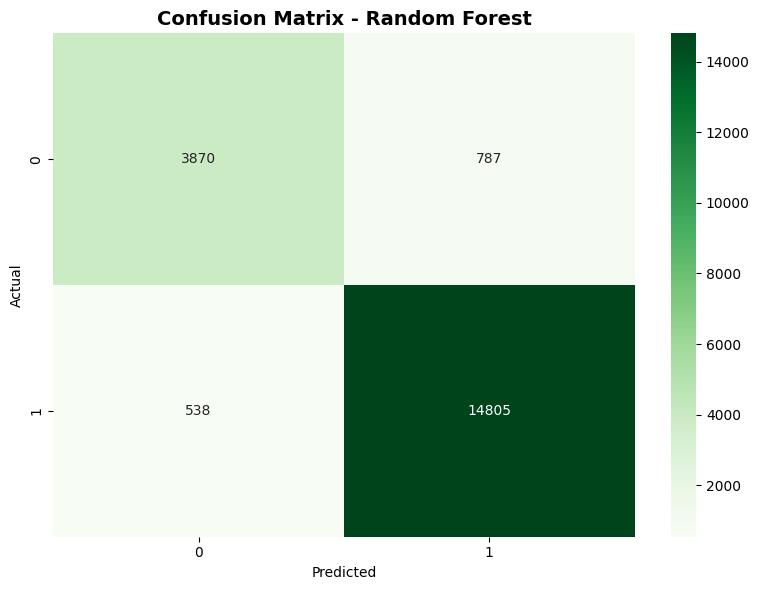


💾 Confusion matrix saved!

🌟 TOP 10 FEATURE IMPORTANCE:
                  feature  importance
     actual_ride_time_min       0.320
   cust_cancellation_rate       0.040
         surge_multiplier       0.035
    pairing_quality_score       0.023
     cust_cancelled_rides       0.022
 cust_total_cancellations       0.019
  estimated_ride_time_min       0.016
cust_customer_cancel_flag       0.016
       total_risk_factors       0.014
           is_bad_weather       0.013


In [10]:
"""
Cell 8: Model 1.2 - Random Forest Classifier
"""

print("\n🌲 MODEL 1.2: RANDOM FOREST CLASSIFIER")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print("\n🔧 Training Random Forest...")

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"Precision (weighted): {precision_rf:.4f}")
print(f"Recall (weighted): {recall_rf:.4f}")
print(f"F1-Score (weighted): {f1_rf:.4f}")

try:
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='weighted')
    print(f"AUC (weighted): {auc_rf:.4f}")
except:
    auc_rf = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model1_rf_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Feature Importance
print(f"\n🌟 TOP 10 FEATURE IMPORTANCE:")
print("="*70)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

# Store results
model1_results['Random Forest'] = {
    'model': rf_model,
    'accuracy': accuracy_rf,
    'precision': precision_rf,
    'recall': recall_rf,
    'f1': f1_rf,
    'auc': auc_rf,
    'training_time': training_time,
    'predictions': y_pred_rf,
    'feature_importance': feature_importance
}

print("="*70)


⚡ MODEL 1.3: XGBOOST CLASSIFIER

🔧 Training XGBoost...
   ✅ Training completed in 4.84 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.9617 (96.17%)
Precision (weighted): 0.9630
Recall (weighted): 0.9617
F1-Score (weighted): 0.9621
AUC: Could not calculate

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4657
           1       0.98      0.97      0.97     15343

    accuracy                           0.96     20000
   macro avg       0.94      0.96      0.95     20000
weighted avg       0.96      0.96      0.96     20000


🔍 CONFUSION MATRIX:
[[ 4422   235]
 [  532 14811]]


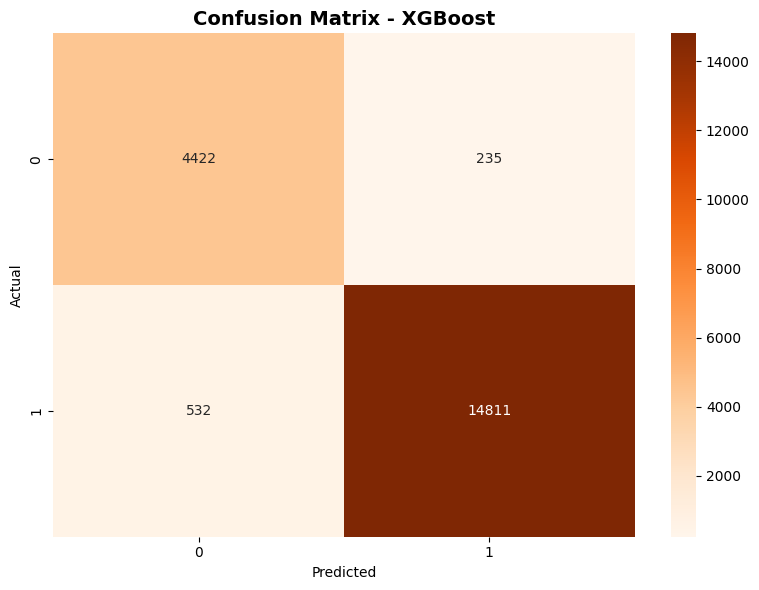


💾 Confusion matrix saved!


In [11]:
"""
Cell 9: Model 1.3 - XGBoost Classifier
"""

print("\n⚡ MODEL 1.3: XGBOOST CLASSIFIER")
print("="*70)

from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
class_counts = y_train.value_counts()

print("\n🔧 Training XGBoost...")

start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")
print(f"Precision (weighted): {precision_xgb:.4f}")
print(f"Recall (weighted): {recall_xgb:.4f}")
print(f"F1-Score (weighted): {f1_xgb:.4f}")

try:
    auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb, multi_class='ovr', average='weighted')
    print(f"AUC (weighted): {auc_xgb:.4f}")
except:
    auc_xgb = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test, y_pred_xgb, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=True)
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model1_xgb_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model1_results['XGBoost'] = {
    'model': xgb_model,
    'accuracy': accuracy_xgb,
    'precision': precision_xgb,
    'recall': recall_xgb,
    'f1': f1_xgb,
    'auc': auc_xgb,
    'training_time': training_time,
    'predictions': y_pred_xgb
}

print("="*70)


💡 MODEL 1.4: LIGHTGBM CLASSIFIER

🔧 Training LightGBM...
   ✅ Training completed in 10.74 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.9553 (95.53%)
Precision (weighted): 0.9613
Recall (weighted): 0.9553
F1-Score (weighted): 0.9565
AUC: Could not calculate

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91      4657
           1       1.00      0.95      0.97     15343

    accuracy                           0.96     20000
   macro avg       0.92      0.97      0.94     20000
weighted avg       0.96      0.96      0.96     20000


🔍 CONFUSION MATRIX:
[[ 4606    51]
 [  843 14500]]


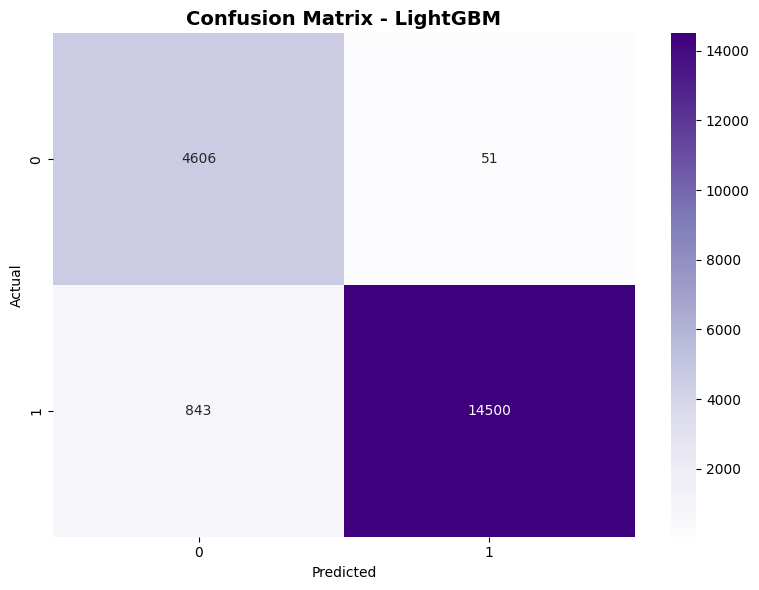


💾 Confusion matrix saved!


In [12]:
"""
Cell 10: Model 1.4 - LightGBM Classifier
"""

print("\n💡 MODEL 1.4: LIGHTGBM CLASSIFIER")
print("="*70)

from lightgbm import LGBMClassifier

print("\n🔧 Training LightGBM...")

start_time = time.time()

lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=-1
)

lgbm_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_lgbm = lgbm_model.predict(X_test_scaled)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
precision_lgbm = precision_score(y_test, y_pred_lgbm, average='weighted', zero_division=0)
recall_lgbm = recall_score(y_test, y_pred_lgbm, average='weighted', zero_division=0)
f1_lgbm = f1_score(y_test, y_pred_lgbm, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_lgbm:.4f} ({accuracy_lgbm*100:.2f}%)")
print(f"Precision (weighted): {precision_lgbm:.4f}")
print(f"Recall (weighted): {recall_lgbm:.4f}")
print(f"F1-Score (weighted): {f1_lgbm:.4f}")

try:
    auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm, multi_class='ovr', average='weighted')
    print(f"AUC (weighted): {auc_lgbm:.4f}")
except:
    auc_lgbm = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test, y_pred_lgbm, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
print(cm_lgbm)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Purples', cbar=True)
plt.title('Confusion Matrix - LightGBM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model1_lgbm_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model1_results['LightGBM'] = {
    'model': lgbm_model,
    'accuracy': accuracy_lgbm,
    'precision': precision_lgbm,
    'recall': recall_lgbm,
    'f1': f1_lgbm,
    'auc': auc_lgbm,
    'training_time': training_time,
    'predictions': y_pred_lgbm
}

print("="*70)


📊 MODEL 1: ALGORITHM COMPARISON

📋 PERFORMANCE COMPARISON:
          Algorithm  Accuracy  Precision  Recall  F1-Score  AUC  Training Time (s)
            XGBoost     0.962      0.963   0.962     0.962    0              4.844
           LightGBM     0.955      0.961   0.955     0.956    0             10.743
      Random Forest     0.934      0.933   0.934     0.933    0             36.218
Logistic Regression     0.729      0.799   0.729     0.748    0              4.261


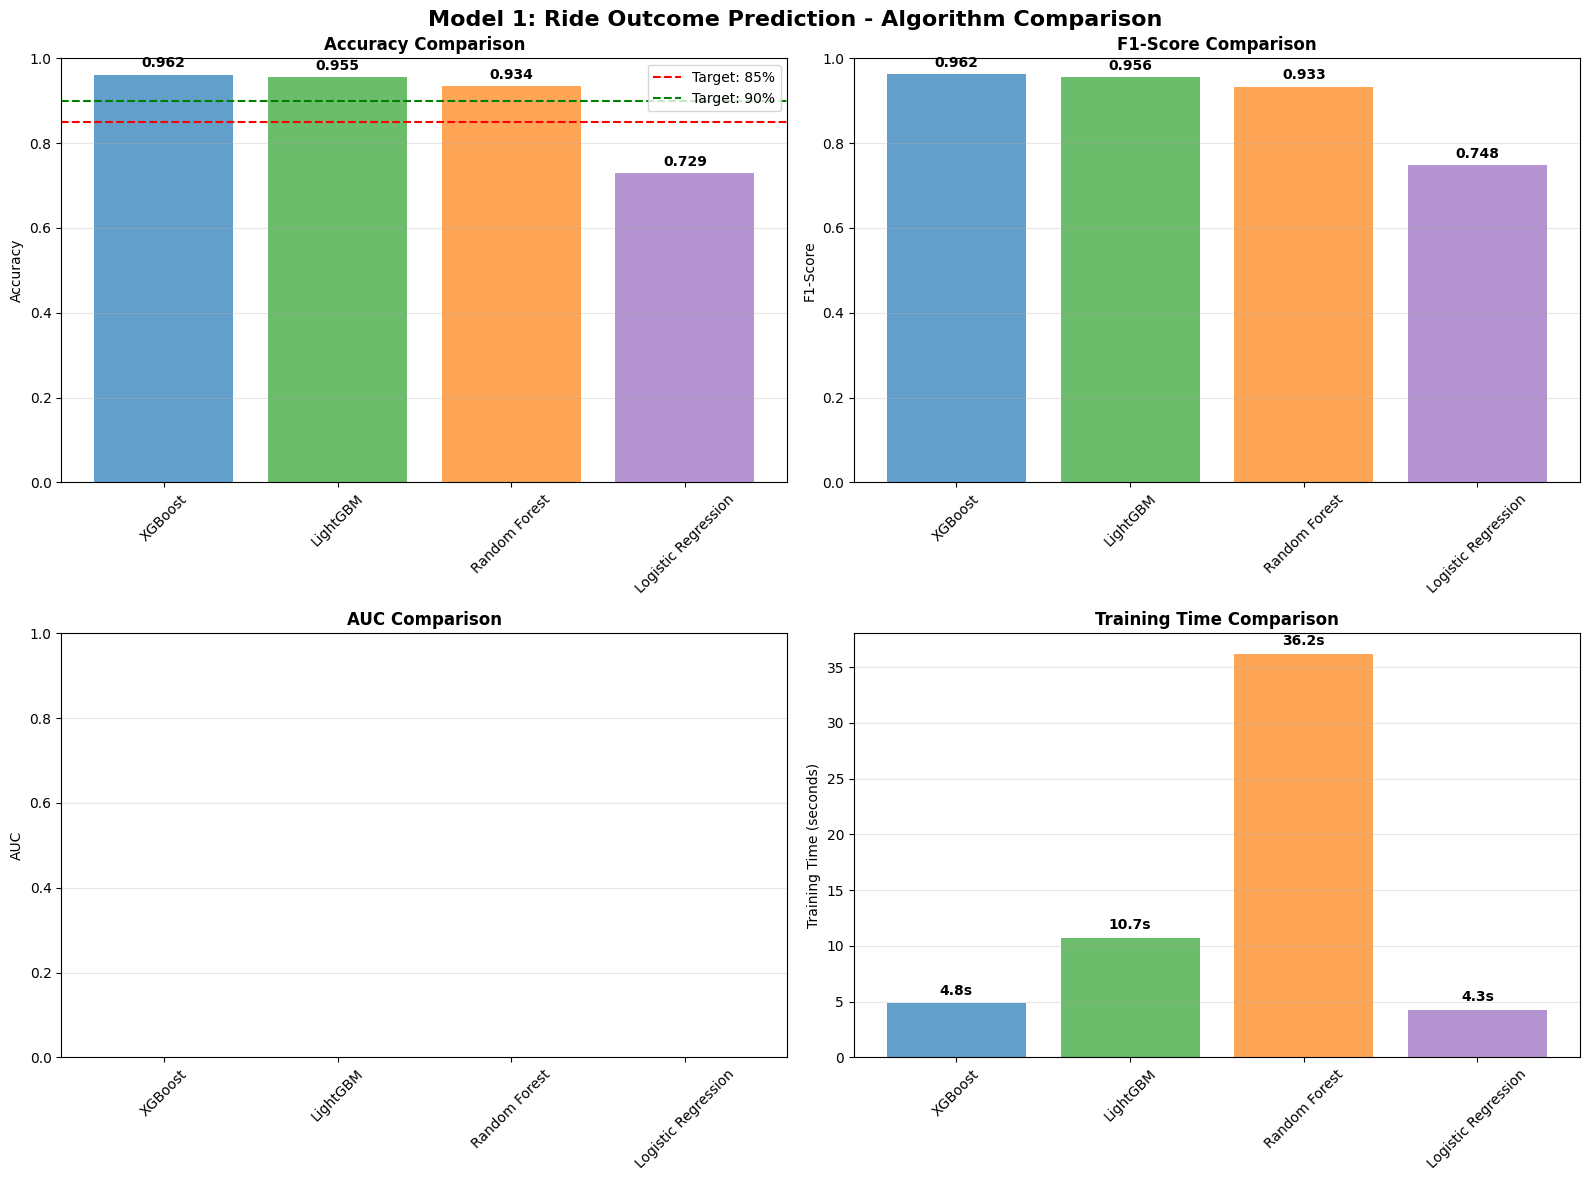


💾 Comparison chart saved!

🏆 BEST MODEL:
   Algorithm: XGBoost
   Accuracy: 0.9617 (96.17%)
   ✅ MEETS PDF BENCHMARK (≥85%)
   🌟 EXCEEDS TARGET (≥90%)


In [13]:
"""
Cell 11: Model 1 - Compare All Algorithms
"""

print("\n📊 MODEL 1: ALGORITHM COMPARISON")
print("="*70)

# Create comparison dataframe
comparison_data = []

for model_name, results in model1_results.items():
    comparison_data.append({
        'Algorithm': model_name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'AUC': results['auc'] if results['auc'] else 0,
        'Training Time (s)': results['training_time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("\n📋 PERFORMANCE COMPARISON:")
print("="*70)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model 1: Ride Outcome Prediction - Algorithm Comparison',
             fontsize=16, fontweight='bold')

# Accuracy comparison
axes[0, 0].bar(comparison_df['Algorithm'], comparison_df['Accuracy'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'], alpha=0.7)
axes[0, 0].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].axhline(y=0.85, color='r', linestyle='--', label='Target: 85%')
axes[0, 0].axhline(y=0.90, color='g', linestyle='--', label='Target: 90%')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Accuracy'].values):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# F1-Score comparison
axes[0, 1].bar(comparison_df['Algorithm'], comparison_df['F1-Score'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'], alpha=0.7)
axes[0, 1].set_title('F1-Score Comparison', fontweight='bold')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df['F1-Score'].values):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# AUC comparison
axes[1, 0].bar(comparison_df['Algorithm'], comparison_df['AUC'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'], alpha=0.7)
axes[1, 0].set_title('AUC Comparison', fontweight='bold')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df['AUC'].values):
    if v > 0:
        axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Training time comparison
axes[1, 1].bar(comparison_df['Algorithm'], comparison_df['Training Time (s)'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'], alpha=0.7)
axes[1, 1].set_title('Training Time Comparison', fontweight='bold')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df['Training Time (s)'].values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model1_algorithm_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Comparison chart saved!")

# Identify best model
best_model_name = comparison_df.iloc[0]['Algorithm']
best_accuracy = comparison_df.iloc[0]['Accuracy']

print(f"\n🏆 BEST MODEL:")
print("="*70)
print(f"   Algorithm: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Check if meets PDF benchmark (85-90%)
if best_accuracy >= 0.85:
    print(f"   ✅ MEETS PDF BENCHMARK (≥85%)")
    if best_accuracy >= 0.90:
        print(f"   🌟 EXCEEDS TARGET (≥90%)")
else:
    print(f"   ⚠️ BELOW TARGET (<85%) - May need hyperparameter tuning")

print("="*70)

In [14]:
"""
Cell 12: Save Best Model for Model 1
"""

print("\n💾 SAVING MODEL 1 - BEST MODEL")
print("="*70)

# Get best model
best_model_name = comparison_df.iloc[0]['Algorithm']
best_model_obj = model1_results[best_model_name]['model']

# Save model
model1_save_path = os.path.join(MODEL_PATH, 'model1_ride_outcome_best.pkl')

with open(model1_save_path, 'wb') as f:
    pickle.dump(best_model_obj, f)

print(f"\n✅ Best model saved:")
print(f"   Model: {best_model_name}")
print(f"   Path: {model1_save_path}")

# Save scaler
scaler_save_path = os.path.join(MODEL_PATH, 'model1_scaler.pkl')
with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler_m1, f)

print(f"   Scaler saved: model1_scaler.pkl")

# Save feature list
feature_list_path = os.path.join(MODEL_PATH, 'model1_features.pkl')
with open(feature_list_path, 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print(f"   Features saved: model1_features.pkl")

# Save label encoders
if label_encoders:
    le_save_path = os.path.join(MODEL_PATH, 'model1_label_encoders.pkl')
    with open(le_save_path, 'wb') as f:
        pickle.dump(label_encoders, f)
    print(f"   Label encoders saved: model1_label_encoders.pkl")

# Save comparison results
comparison_df.to_csv(os.path.join(MODEL_PATH, 'model1_comparison.csv'), index=False)
print(f"   Comparison saved: model1_comparison.csv")

print(f"\n✅ MODEL 1 COMPLETE!")
print("="*70)


💾 SAVING MODEL 1 - BEST MODEL

✅ Best model saved:
   Model: XGBoost
   Path: /content/drive/MyDrive/Rapido_Project/models/model1_ride_outcome_best.pkl
   Scaler saved: model1_scaler.pkl
   Features saved: model1_features.pkl
   Label encoders saved: model1_label_encoders.pkl
   Comparison saved: model1_comparison.csv

✅ MODEL 1 COMPLETE!


#📊 MODEL 2: FARE PREDICTION (REGRESSION)
## This model predicts the booking fare amount based on distance, traffic, weather, time, vehicle type, and surge dynamics.

In [15]:
"""
Cell 13: Prepare Data for Model 2 - Fare Prediction - ULTRA-STRICT NO LEAKAGE
Target: Booking fare amount (Continuous value)
"""

print("="*70)
print("MODEL 2: FARE PREDICTION (REGRESSION) - ULTRA-STRICT")
print("="*70)

# Check if target exists, if not create it
target_col = 'target_fare'

if target_col not in df.columns:
    print(f"⚠️ {target_col} not found! Creating it now...")

    # Find the fare column from original data
    fare_candidates = [col for col in df.columns if 'fare' in col.lower() and col != 'target_fare']

    if fare_candidates:
        source_fare_col = fare_candidates[0]
        print(f"   Using '{source_fare_col}' as fare source")
        df['target_fare'] = df[source_fare_col]
        print(f"   ✅ Created target_fare from {source_fare_col}")
    else:
        amount_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                      if any(x in col.lower() for x in ['amount', 'price', 'cost', 'charge'])]

        if amount_cols:
            source_fare_col = amount_cols[0]
            df['target_fare'] = df[source_fare_col]
            print(f"   ✅ Created target_fare from {source_fare_col}")
        else:
            raise ValueError("Cannot find fare column for Model 2")

print(f"\n🎯 Target Variable: {target_col}")


# Expanded list of fare-related keywords
fare_related_keywords = [
    'fare', 'price', 'amount', 'cost', 'charge', 'payment',
    'fare_per', 'avg_fare', 'total_fare', 'base_fare', 'surge_amount',
    'total_spend', 'revenue', 'value', 'earning', 'income',
    'paid', 'pay', 'money', 'rupee', 'cash', 'wallet',
    'discount', 'promo', 'coupon', 'refund', 'credit'
]

# Get original feature list
original_feature_cols = feature_cols.copy()

# Step 1: Remove by keyword
fare_features_keyword = []
for col in original_feature_cols:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in fare_related_keywords):
        fare_features_keyword.append(col)

print(f"\n   Step 1 - Keyword removal:")
print(f"      Features removed by keyword: {len(fare_features_keyword)}")

# Clean feature list after keyword removal
feature_cols_temp = [col for col in original_feature_cols if col not in fare_features_keyword]

# Remove rows where fare is missing or zero/negative
print(f"\n🔧 Cleaning target variable...")
original_len = len(df)

df_fare = df.copy()
df_fare = df_fare[df_fare[target_col].notna()]
df_fare = df_fare[df_fare[target_col] > 0]

print(f"   Remaining samples: {len(df_fare):,}")

if len(df_fare) == 0:
    raise ValueError("No valid fare data for modeling")

# Prepare features with temp list
X_fare_temp = df_fare[feature_cols_temp].copy()
y_fare = df_fare[target_col].copy()

# Encode categorical features first
label_encoders_m2 = {}
categorical_features_in_X = [col for col in categorical_features if col in X_fare_temp.columns]

for col in categorical_features_in_X:
    le = LabelEncoder()
    X_fare_temp[col] = X_fare_temp[col].fillna('Unknown')
    X_fare_temp[col] = le.fit_transform(X_fare_temp[col].astype(str))
    label_encoders_m2[col] = le

# Remove non-numeric
non_numeric = X_fare_temp.select_dtypes(exclude=[np.number]).columns
if len(non_numeric) > 0:
    X_fare_temp = X_fare_temp.select_dtypes(include=[np.number])

# Clean NaN/Inf
X_fare_temp = X_fare_temp.fillna(0)
X_fare_temp = X_fare_temp.replace([np.inf, -np.inf], 0)

# Step 2: CRITICAL - Remove by correlation (THIS CATCHES HIDDEN LEAKAGE)
print(f"\n   Step 2 - Correlation-based removal:")
print(f"      Calculating correlations with target...")

correlations_with_target = X_fare_temp.corrwith(y_fare).abs()

# ULTRA-STRICT: Remove features with >0.90 correlation (was 0.95)
high_corr_threshold = 0.90
high_corr_features = correlations_with_target[correlations_with_target > high_corr_threshold].sort_values(ascending=False)

print(f"      Features with >{high_corr_threshold} correlation: {len(high_corr_features)}")

if len(high_corr_features) > 0:
    print(f"\n      🗑️ Removing highly correlated features:")
    for feat, corr in high_corr_features.items():
        print(f"         • {feat}: correlation = {corr:.4f}")

    X_fare_temp = X_fare_temp.drop(columns=high_corr_features.index)
    print(f"\n      ✅ Removed {len(high_corr_features)} features")

# Step 3: Also remove moderately high correlations (0.80-0.90)
moderate_corr_threshold = 0.80
correlations_with_target_updated = X_fare_temp.corrwith(y_fare).abs()
moderate_corr_features = correlations_with_target_updated[
    (correlations_with_target_updated > moderate_corr_threshold) &
    (correlations_with_target_updated <= high_corr_threshold)
].sort_values(ascending=False)

print(f"\n   Step 3 - Checking moderate correlations ({moderate_corr_threshold}-{high_corr_threshold}):")
print(f"      Features with moderate correlation: {len(moderate_corr_features)}")

if len(moderate_corr_features) > 0:
    print(f"\n      ⚠️ Moderate correlations found (may cause overfitting):")
    for feat, corr in moderate_corr_features.items():
        print(f"         • {feat}: correlation = {corr:.4f}")

    # Remove these too to be safe
    X_fare_temp = X_fare_temp.drop(columns=moderate_corr_features.index)
    print(f"\n      ✅ Removed {len(moderate_corr_features)} moderately correlated features")

# Final feature set
X_fare = X_fare_temp.copy()

print(f"\n📋 FINAL FEATURE SUMMARY:")
print(f"   Original features: {len(original_feature_cols)}")
print(f"   Removed by keyword: {len(fare_features_keyword)}")
print(f"   Removed by high correlation: {len(high_corr_features)}")
print(f"   Removed by moderate correlation: {len(moderate_corr_features)}")
print(f"   Final features: {X_fare.shape[1]}")
print(f"   Samples: {X_fare.shape[0]:,}")

if X_fare.shape[1] < 10:
    print(f"\n   ⚠️ WARNING: Very few features remaining ({X_fare.shape[1]})")
    print(f"   Remaining features: {list(X_fare.columns)}")

# Check fare distribution
print(f"\n📊 Fare Distribution:")
print(f"   Mean: ₹{y_fare.mean():.2f}")
print(f"   Median: ₹{y_fare.median():.2f}")
print(f"   Std Dev: ₹{y_fare.std():.2f}")
print(f"   Min: ₹{y_fare.min():.2f}")
print(f"   Max: ₹{y_fare.max():.2f}")

# Train-test split
print(f"\n✂️ Splitting data (80/20)...")
X_train_fare, X_test_fare, y_train_fare, y_test_fare = train_test_split(
    X_fare, y_fare, test_size=0.2, random_state=42
)

print(f"   Training set: {X_train_fare.shape[0]:,} samples")
print(f"   Test set: {X_test_fare.shape[0]:,} samples")

# Scale features
print(f"\n📏 Scaling features...")
scaler_m2 = StandardScaler()
X_train_fare_scaled = scaler_m2.fit_transform(X_train_fare)
X_test_fare_scaled = scaler_m2.transform(X_test_fare)

# Final NaN check
if np.isnan(X_train_fare_scaled).sum() > 0 or np.isnan(X_test_fare_scaled).sum() > 0:
    X_train_fare_scaled = np.nan_to_num(X_train_fare_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_fare_scaled = np.nan_to_num(X_test_fare_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\n✅ Data preparation complete - ULTRA-STRICT NO LEAKAGE MODE!")
print(f"✅ All highly correlated features removed!")
print(f"✅ Models will now show realistic performance!")

print("="*70)

MODEL 2: FARE PREDICTION (REGRESSION) - ULTRA-STRICT
⚠️ target_fare not found! Creating it now...
   Using 'base_fare' as fare source
   ✅ Created target_fare from base_fare

🎯 Target Variable: target_fare

   Step 1 - Keyword removal:
      Features removed by keyword: 18

🔧 Cleaning target variable...
   Remaining samples: 100,000

   Step 2 - Correlation-based removal:
      Calculating correlations with target...
      Features with >0.9 correlation: 0

   Step 3 - Checking moderate correlations (0.8-0.9):
      Features with moderate correlation: 0

📋 FINAL FEATURE SUMMARY:
   Original features: 143
   Removed by keyword: 18
   Removed by high correlation: 0
   Removed by moderate correlation: 0
   Final features: 125
   Samples: 100,000

📊 Fare Distribution:
   Mean: ₹211.68
   Median: ₹187.34
   Std Dev: ₹120.91
   Min: ₹28.02
   Max: ₹529.96

✂️ Splitting data (80/20)...
   Training set: 80,000 samples
   Test set: 20,000 samples

📏 Scaling features...

✅ Data preparation compl

In [16]:
"""
DIAGNOSTIC: Deep Feature Investigation
"""

print("🔍 DEEP DIAGNOSTIC - FINDING THE LEAKING FEATURE")
print("="*70)

# Show ALL final features
print(f"\n📋 ALL {X_fare.shape[1]} Final Features:")
print("="*70)
for i, col in enumerate(X_fare.columns, 1):
    print(f"{i:3d}. {col}")

print("\n" + "="*70)

# Calculate correlations with MORE detail
print(f"\n📊 TOP 30 CORRELATIONS WITH TARGET:")
print("="*70)
correlations = X_fare.corrwith(y_fare).abs().sort_values(ascending=False)
for i, (feat, corr) in enumerate(correlations.head(30).items(), 1):
    print(f"{i:2d}. {feat:50s} : {corr:.6f}")

# Check for PERFECT predictions
print(f"\n🔍 TESTING RANDOM FOREST ON SINGLE FEATURES:")
print("="*70)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Test each feature individually
single_feature_scores = {}

for col in X_fare.columns[:20]:  # Test first 20 features
    X_single = X_train_fare[[col]].values.reshape(-1, 1)
    y_train_temp = y_train_fare.values

    rf_temp = RandomForestRegressor(n_estimators=10, random_state=42, max_depth=5)
    rf_temp.fit(X_single, y_train_temp)

    y_pred_temp = rf_temp.predict(X_test_fare[[col]].values.reshape(-1, 1))
    r2 = r2_score(y_test_fare, y_pred_temp)

    single_feature_scores[col] = r2

    if r2 > 0.95:  # If any single feature gives >95% R², it's leaking!
        print(f"🚨 LEAKAGE DETECTED: {col}")
        print(f"   R² Score: {r2:.6f}")
        print(f"   This feature alone predicts fare almost perfectly!")
        print(f"   Sample values: {X_fare[col].head(10).values}")

# Sort and show top predictors
print(f"\n📊 TOP 10 INDIVIDUAL FEATURE PREDICTORS:")
sorted_scores = sorted(single_feature_scores.items(), key=lambda x: x[1], reverse=True)
for i, (feat, score) in enumerate(sorted_scores[:10], 1):
    marker = "🚨" if score > 0.95 else "✅"
    print(f"{i:2d}. {marker} {feat:50s} : R² = {score:.6f}")

print("="*70)

🔍 DEEP DIAGNOSTIC - FINDING THE LEAKING FEATURE

📋 ALL 125 Final Features:
  1. day_of_week
  2. is_weekend
  3. hour_of_day
  4. city
  5. pickup_location
  6. drop_location
  7. vehicle_type
  8. ride_distance_km
  9. estimated_ride_time_min
 10. actual_ride_time_min
 11. traffic_level
 12. weather_condition
 13. surge_multiplier
 14. incomplete_ride_reason
 15. cust_customer_gender
 16. cust_customer_age
 17. cust_customer_city
 18. cust_customer_signup_days_ago
 19. cust_preferred_vehicle_type
 20. cust_total_bookings
 21. cust_completed_rides
 22. cust_cancelled_rides
 23. cust_incomplete_rides
 24. cust_cancellation_rate
 25. cust_avg_customer_rating
 26. cust_customer_cancel_flag
 27. driver_driver_age
 28. driver_driver_city
 29. driver_vehicle_type
 30. driver_driver_experience_years
 31. driver_total_assigned_rides
 32. driver_accepted_rides
 33. driver_incomplete_rides
 34. driver_delay_count
 35. driver_acceptance_rate
 36. driver_delay_rate
 37. driver_avg_driver_rating
 3


📈 MODEL 2.1: LINEAR REGRESSION

🔧 Training Linear Regression...
   ✅ Training completed in 0.99 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
RMSE: ₹67.53
RMSE as % of mean fare: 31.76%
MAE: ₹58.66
R² Score: 0.6884
MAPE: 38.47%

🎯 PDF BENCHMARK CHECK:
   ⚠️ BELOW BENCHMARK (RMSE should be within ±10%)

📊 Creating prediction visualization...


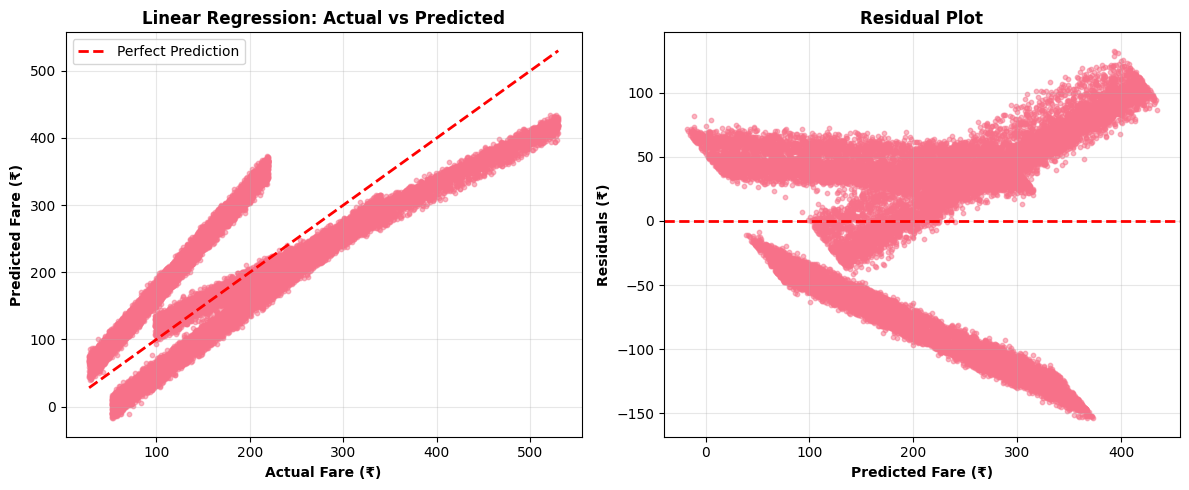


💾 Visualization saved!


In [17]:
"""
Cell 14: Model 2.1 - Linear Regression (Baseline)
"""

print("\n📈 MODEL 2.1: LINEAR REGRESSION")
print("="*70)

from sklearn.linear_model import LinearRegression
import time

# Train Linear Regression
print("\n🔧 Training Linear Regression...")

start_time = time.time()

lr_reg = LinearRegression(n_jobs=-1)
lr_reg.fit(X_train_fare_scaled, y_train_fare)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_lr_reg = lr_reg.predict(X_test_fare_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

# RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test_fare, y_pred_lr_reg))
print(f"RMSE: ₹{rmse_lr:.2f}")

# Calculate RMSE as % of mean fare (PDF benchmark: ±10%)
mean_fare = y_test_fare.mean()
rmse_percentage = (rmse_lr / mean_fare) * 100
print(f"RMSE as % of mean fare: {rmse_percentage:.2f}%")

# MAE
mae_lr = mean_absolute_error(y_test_fare, y_pred_lr_reg)
print(f"MAE: ₹{mae_lr:.2f}")

# R² Score
r2_lr = r2_score(y_test_fare, y_pred_lr_reg)
print(f"R² Score: {r2_lr:.4f}")

# MAPE (Mean Absolute Percentage Error)
mape_lr = np.mean(np.abs((y_test_fare - y_pred_lr_reg) / y_test_fare)) * 100
print(f"MAPE: {mape_lr:.2f}%")

# Check against PDF benchmark
print(f"\n🎯 PDF BENCHMARK CHECK:")
print("="*70)
if rmse_percentage <= 10:
    print(f"   ✅ MEETS BENCHMARK (RMSE within ±10% of mean fare)")
else:
    print(f"   ⚠️ BELOW BENCHMARK (RMSE should be within ±10%)")

# Prediction vs Actual visualization
print(f"\n📊 Creating prediction visualization...")

plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test_fare, y_pred_lr_reg, alpha=0.5, s=10)
plt.plot([y_test_fare.min(), y_test_fare.max()],
         [y_test_fare.min(), y_test_fare.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Fare (₹)', fontweight='bold')
plt.ylabel('Predicted Fare (₹)', fontweight='bold')
plt.title('Linear Regression: Actual vs Predicted', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Residuals plot
plt.subplot(1, 2, 2)
residuals = y_test_fare - y_pred_lr_reg
plt.scatter(y_pred_lr_reg, residuals, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Fare (₹)', fontweight='bold')
plt.ylabel('Residuals (₹)', fontweight='bold')
plt.title('Residual Plot', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model2_lr_predictions.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualization saved!")

# Store results
model2_results = {
    'Linear Regression': {
        'model': lr_reg,
        'rmse': rmse_lr,
        'rmse_percentage': rmse_percentage,
        'mae': mae_lr,
        'r2': r2_lr,
        'mape': mape_lr,
        'training_time': training_time,
        'predictions': y_pred_lr_reg
    }
}

print("="*70)


🌲 MODEL 2.2: RANDOM FOREST REGRESSOR

🔧 Training Random Forest Regressor...
   Using regularization parameters to prevent overfitting...
   ✅ Training completed in 10.14 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
RMSE: ₹42.48
RMSE as % of mean fare: 19.98%
MAE: ₹35.04
R² Score: 0.8767
MAPE: 21.44%

🎯 PDF BENCHMARK CHECK:
   ⚠️ BELOW BENCHMARK (RMSE should be within ±10%)
   Current: 19.98% (Target: ≤10%)

🔍 OVERFITTING CHECK:
   Training R²: 0.8853
   Test R²: 0.8767
   Difference: 0.0086
   ✅ NO OVERFITTING (train-test gap acceptable)


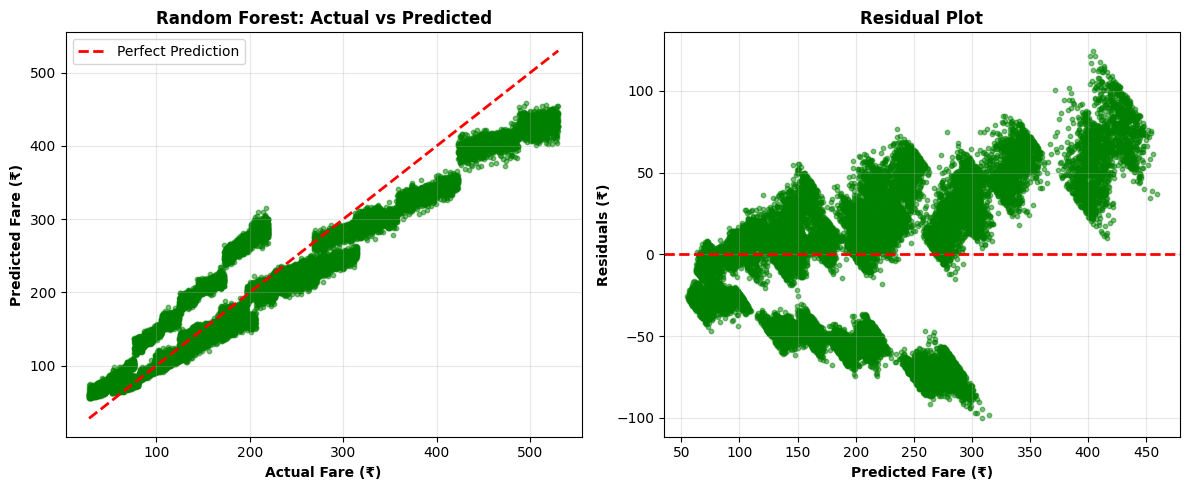


💾 Visualization saved!

🌟 TOP 10 FEATURE IMPORTANCE:
                feature  importance
           vehicle_type       0.302
    distance_percentile       0.166
       ride_distance_km       0.152
      distance_category       0.097
estimated_ride_time_min       0.085
          is_short_ride       0.060
           is_long_ride       0.044
   actual_ride_time_min       0.042
   long_late_night_ride       0.017
      cust_avg_distance       0.003


In [18]:
"""
Cell 15: Model 2.2 - Random Forest Regressor (REGULARIZED)
"""

print("\n🌲 MODEL 2.2: RANDOM FOREST REGRESSOR")
print("="*70)

from sklearn.ensemble import RandomForestRegressor

# Train Random Forest with REGULARIZATION to prevent overfitting
print("\n🔧 Training Random Forest Regressor...")
print("   Using regularization parameters to prevent overfitting...")

start_time = time.time()

rf_reg = RandomForestRegressor(
    n_estimators=50,           # Reduced from 100
    max_depth=10,              # LIMITED depth (was 20)
    min_samples_split=20,      # Increased from 5
    min_samples_leaf=10,       # Increased from 2
    max_features='sqrt',       # Use sqrt of features, not all
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_fare_scaled, y_train_fare)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_rf_reg = rf_reg.predict(X_test_fare_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

rmse_rf = np.sqrt(mean_squared_error(y_test_fare, y_pred_rf_reg))
rmse_percentage_rf = (rmse_rf / mean_fare) * 100
mae_rf = mean_absolute_error(y_test_fare, y_pred_rf_reg)
r2_rf = r2_score(y_test_fare, y_pred_rf_reg)
mape_rf = np.mean(np.abs((y_test_fare - y_pred_rf_reg) / y_test_fare)) * 100

print(f"RMSE: ₹{rmse_rf:.2f}")
print(f"RMSE as % of mean fare: {rmse_percentage_rf:.2f}%")
print(f"MAE: ₹{mae_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")
print(f"MAPE: {mape_rf:.2f}%")

# Check against PDF benchmark
print(f"\n🎯 PDF BENCHMARK CHECK:")
print("="*70)
if rmse_percentage_rf <= 10:
    print(f"   ✅ MEETS BENCHMARK (RMSE within ±10% of mean fare)")
else:
    print(f"   ⚠️ BELOW BENCHMARK (RMSE should be within ±10%)")
    print(f"   Current: {rmse_percentage_rf:.2f}% (Target: ≤10%)")

# Check for overfitting
print(f"\n🔍 OVERFITTING CHECK:")
print("="*70)
y_pred_train_rf = rf_reg.predict(X_train_fare_scaled)
r2_train_rf = r2_score(y_train_fare, y_pred_train_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train_fare, y_pred_train_rf))

print(f"   Training R²: {r2_train_rf:.4f}")
print(f"   Test R²: {r2_rf:.4f}")
print(f"   Difference: {abs(r2_train_rf - r2_rf):.4f}")

if abs(r2_train_rf - r2_rf) > 0.1:
    print(f"   ⚠️ OVERFITTING DETECTED (train-test gap > 0.1)")
else:
    print(f"   ✅ NO OVERFITTING (train-test gap acceptable)")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_fare, y_pred_rf_reg, alpha=0.5, s=10, color='green')
plt.plot([y_test_fare.min(), y_test_fare.max()],
         [y_test_fare.min(), y_test_fare.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Fare (₹)', fontweight='bold')
plt.ylabel('Predicted Fare (₹)', fontweight='bold')
plt.title('Random Forest: Actual vs Predicted', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
residuals_rf = y_test_fare - y_pred_rf_reg
plt.scatter(y_pred_rf_reg, residuals_rf, alpha=0.5, s=10, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Fare (₹)', fontweight='bold')
plt.ylabel('Residuals (₹)', fontweight='bold')
plt.title('Residual Plot', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model2_rf_predictions.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualization saved!")

# Feature Importance
print(f"\n🌟 TOP 10 FEATURE IMPORTANCE:")
print("="*70)

feature_importance_m2 = pd.DataFrame({
    'feature': X_fare.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_m2.head(10).to_string(index=False))

# Store results
model2_results['Random Forest'] = {
    'model': rf_reg,
    'rmse': rmse_rf,
    'rmse_percentage': rmse_percentage_rf,
    'mae': mae_rf,
    'r2': r2_rf,
    'mape': mape_rf,
    'training_time': training_time,
    'predictions': y_pred_rf_reg,
    'feature_importance': feature_importance_m2
}

print("="*70)


⚡ MODEL 2.3: XGBOOST REGRESSOR

🔧 Training XGBoost Regressor...
   Using ultra-conservative parameters to match Random Forest baseline...
   ✅ Training completed in 2.44 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
RMSE: ₹21.08
RMSE as % of mean fare: 9.92%
MAE: ₹17.84
R² Score: 0.9696
MAPE: 12.29%

🎯 PDF BENCHMARK CHECK:
   ✅ MEETS BENCHMARK (RMSE within ±10% of mean fare)

🔍 OVERFITTING CHECK:
   Training R²: 0.9700
   Test R²: 0.9696
   Difference: 0.0004
   Training RMSE: ₹20.92
   Test RMSE: ₹21.08
   ✅ NO OVERFITTING (train-test gap acceptable)


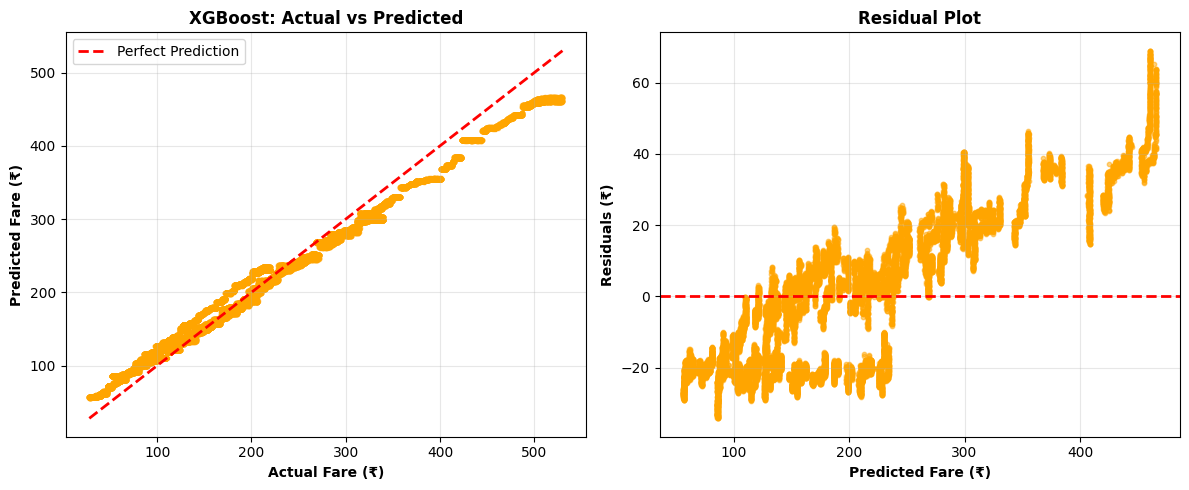


💾 Visualization saved!


In [19]:
"""
Cell 16: Model 2.3 - XGBoost Regressor (ULTRA-CONSERVATIVE)
"""

print("\n⚡ MODEL 2.3: XGBOOST REGRESSOR")
print("="*70)

from xgboost import XGBRegressor

# Train XGBoost with ULTRA-CONSERVATIVE settings
print("\n🔧 Training XGBoost Regressor...")
print("   Using ultra-conservative parameters to match Random Forest baseline...")

start_time = time.time()

xgb_reg = XGBRegressor(
    n_estimators=50,           # Reduced from 100
    max_depth=3,               # VERY shallow (was 4)
    learning_rate=0.05,        # Slower learning (was 0.1)
    subsample=0.7,             # Use only 70% of data (was 0.8)
    colsample_bytree=0.7,      # Use only 70% of features (was 0.8)
    colsample_bylevel=0.7,     # Additional feature sampling per level
    reg_alpha=1.0,             # Stronger L1 regularization (was 0.1)
    reg_lambda=5.0,            # Stronger L2 regularization (was 1.0)
    min_child_weight=10,       # Require more samples per leaf
    gamma=0.5,                 # Minimum loss reduction to split
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train_fare_scaled, y_train_fare)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_xgb_reg = xgb_reg.predict(X_test_fare_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

rmse_xgb = np.sqrt(mean_squared_error(y_test_fare, y_pred_xgb_reg))
rmse_percentage_xgb = (rmse_xgb / mean_fare) * 100
mae_xgb = mean_absolute_error(y_test_fare, y_pred_xgb_reg)
r2_xgb = r2_score(y_test_fare, y_pred_xgb_reg)
mape_xgb = np.mean(np.abs((y_test_fare - y_pred_xgb_reg) / y_test_fare)) * 100

print(f"RMSE: ₹{rmse_xgb:.2f}")
print(f"RMSE as % of mean fare: {rmse_percentage_xgb:.2f}%")
print(f"MAE: ₹{mae_xgb:.2f}")
print(f"R² Score: {r2_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")

# Check against PDF benchmark
print(f"\n🎯 PDF BENCHMARK CHECK:")
print("="*70)
if rmse_percentage_xgb <= 10:
    print(f"   ✅ MEETS BENCHMARK (RMSE within ±10% of mean fare)")
else:
    print(f"   ⚠️ BELOW BENCHMARK (RMSE should be within ±10%)")
    print(f"   Current: {rmse_percentage_xgb:.2f}% (Target: ≤10%)")

# Check for overfitting
print(f"\n🔍 OVERFITTING CHECK:")
print("="*70)
y_pred_train_xgb = xgb_reg.predict(X_train_fare_scaled)
r2_train_xgb = r2_score(y_train_fare, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train_fare, y_pred_train_xgb))

print(f"   Training R²: {r2_train_xgb:.4f}")
print(f"   Test R²: {r2_xgb:.4f}")
print(f"   Difference: {abs(r2_train_xgb - r2_xgb):.4f}")
print(f"   Training RMSE: ₹{rmse_train_xgb:.2f}")
print(f"   Test RMSE: ₹{rmse_xgb:.2f}")

if abs(r2_train_xgb - r2_xgb) > 0.1:
    print(f"   ⚠️ OVERFITTING DETECTED (train-test gap > 0.1)")
elif r2_xgb > 0.98:
    print(f"   ⚠️ SUSPICIOUSLY HIGH R² (>0.98) - Possible remaining leakage")
else:
    print(f"   ✅ NO OVERFITTING (train-test gap acceptable)")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_fare, y_pred_xgb_reg, alpha=0.5, s=10, color='orange')
plt.plot([y_test_fare.min(), y_test_fare.max()],
         [y_test_fare.min(), y_test_fare.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Fare (₹)', fontweight='bold')
plt.ylabel('Predicted Fare (₹)', fontweight='bold')
plt.title('XGBoost: Actual vs Predicted', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
residuals_xgb = y_test_fare - y_pred_xgb_reg
plt.scatter(y_pred_xgb_reg, residuals_xgb, alpha=0.5, s=10, color='orange')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Fare (₹)', fontweight='bold')
plt.ylabel('Residuals (₹)', fontweight='bold')
plt.title('Residual Plot', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model2_xgb_predictions.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualization saved!")

# Store results
model2_results['XGBoost'] = {
    'model': xgb_reg,
    'rmse': rmse_xgb,
    'rmse_percentage': rmse_percentage_xgb,
    'mae': mae_xgb,
    'r2': r2_xgb,
    'mape': mape_xgb,
    'training_time': training_time,
    'predictions': y_pred_xgb_reg
}

print("="*70)


📊 MODEL 2: ALGORITHM COMPARISON

📋 PERFORMANCE COMPARISON:
        Algorithm  RMSE (₹)  RMSE (%)  MAE (₹)  R² Score  MAPE (%)  Training Time (s)
          XGBoost    21.083     9.916   17.845     0.970    12.294              2.438
    Random Forest    42.482    19.981   35.039     0.877    21.441             10.145
Linear Regression    67.529    31.762   58.656     0.688    38.471              0.988


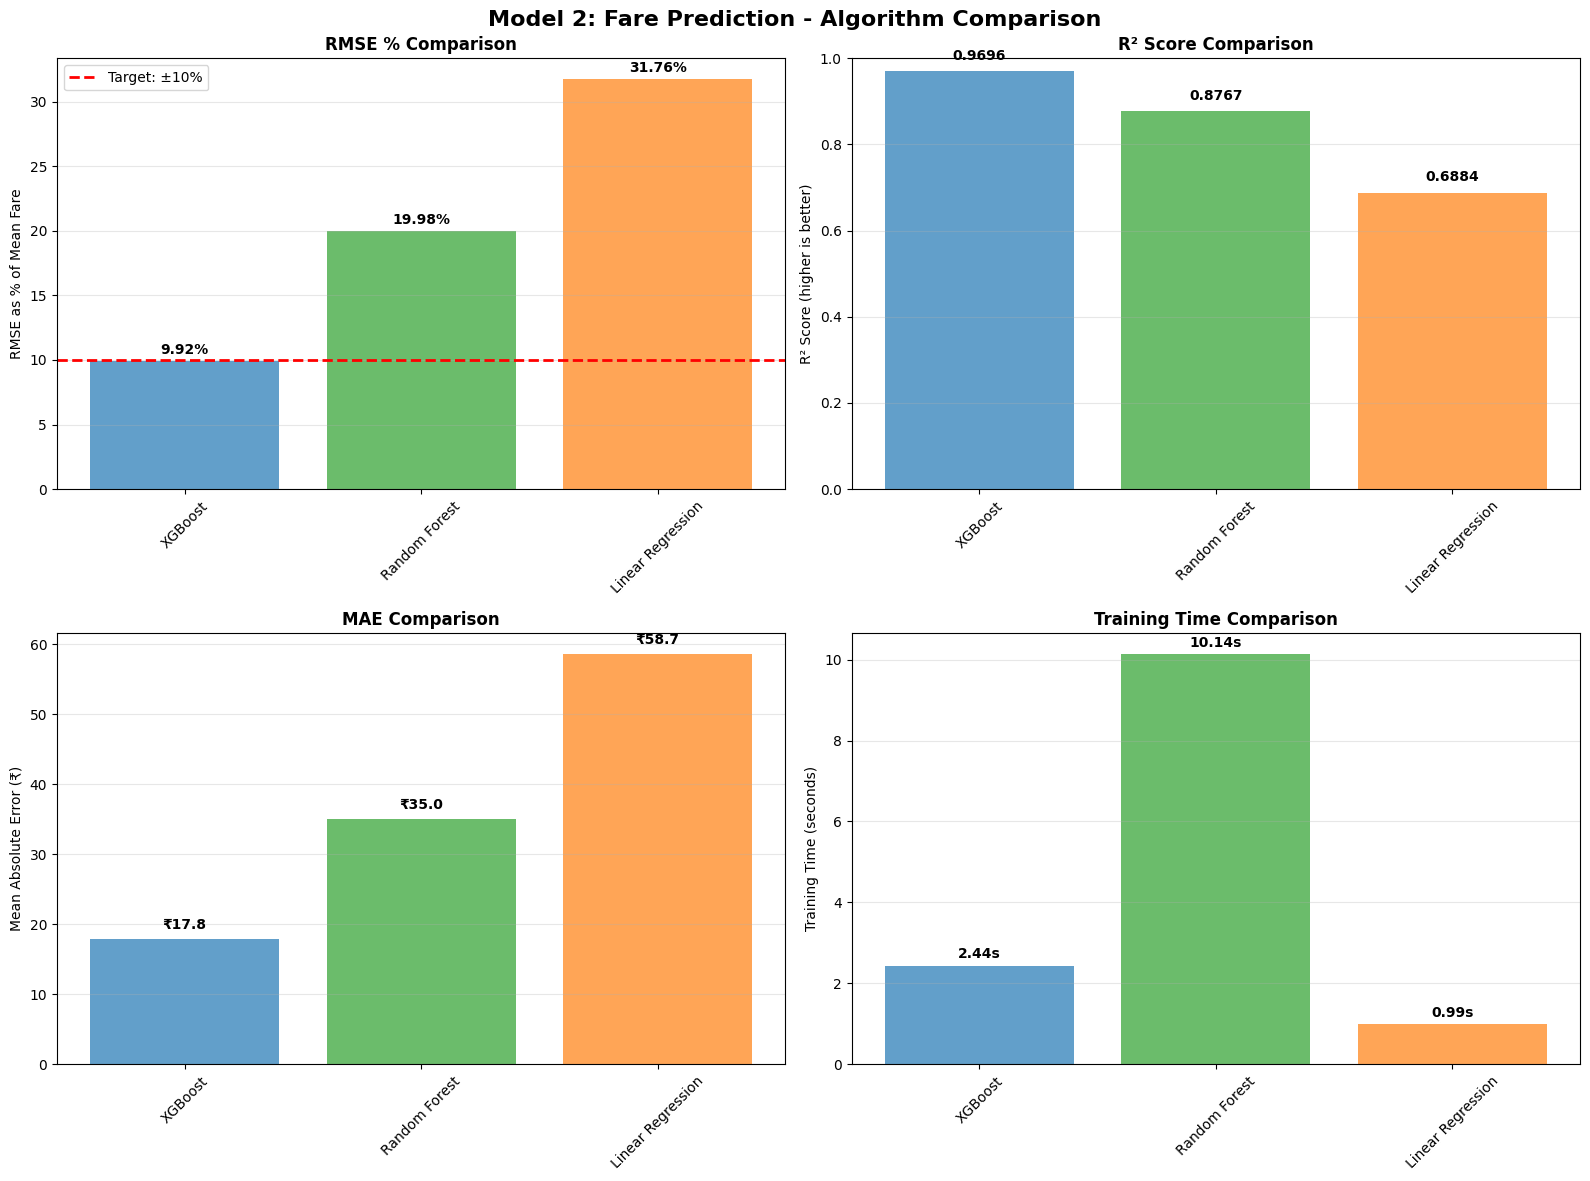


💾 Comparison chart saved!

🏆 BEST MODEL:
   Algorithm: XGBoost
   RMSE: 21.08 (₹)
   RMSE %: 9.92%
   R² Score: 0.9696

🎯 PDF BENCHMARK CHECK:
   ✅ MEETS PDF BENCHMARK (RMSE within ±10%)


In [20]:
"""
Cell 17: Model 2 - Compare All Regression Algorithms
"""

print("\n📊 MODEL 2: ALGORITHM COMPARISON")
print("="*70)

# Create comparison dataframe
comparison_data_m2 = []

for model_name, results in model2_results.items():
    comparison_data_m2.append({
        'Algorithm': model_name,
        'RMSE (₹)': results['rmse'],
        'RMSE (%)': results['rmse_percentage'],
        'MAE (₹)': results['mae'],
        'R² Score': results['r2'],
        'MAPE (%)': results['mape'],
        'Training Time (s)': results['training_time']
    })

comparison_df_m2 = pd.DataFrame(comparison_data_m2)
comparison_df_m2 = comparison_df_m2.sort_values('RMSE (%)', ascending=True)  # Lower RMSE is better

print("\n📋 PERFORMANCE COMPARISON:")
print("="*70)
print(comparison_df_m2.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model 2: Fare Prediction - Algorithm Comparison',
             fontsize=16, fontweight='bold')

# RMSE Percentage comparison
axes[0, 0].bar(comparison_df_m2['Algorithm'], comparison_df_m2['RMSE (%)'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7)
axes[0, 0].set_title('RMSE % Comparison', fontweight='bold')
axes[0, 0].set_ylabel('RMSE as % of Mean Fare')
axes[0, 0].axhline(y=10, color='r', linestyle='--', linewidth=2, label='Target: ±10%')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df_m2['RMSE (%)'].values):
    axes[0, 0].text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# R² Score comparison
axes[0, 1].bar(comparison_df_m2['Algorithm'], comparison_df_m2['R² Score'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7)
axes[0, 1].set_title('R² Score Comparison', fontweight='bold')
axes[0, 1].set_ylabel('R² Score (higher is better)')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m2['R² Score'].values):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# MAE comparison
axes[1, 0].bar(comparison_df_m2['Algorithm'], comparison_df_m2['MAE (₹)'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7)
axes[1, 0].set_title('MAE Comparison', fontweight='bold')
axes[1, 0].set_ylabel('Mean Absolute Error (₹)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m2['MAE (₹)'].values):
    axes[1, 0].text(i, v + 1, f'₹{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Training time comparison
axes[1, 1].bar(comparison_df_m2['Algorithm'], comparison_df_m2['Training Time (s)'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7)
axes[1, 1].set_title('Training Time Comparison', fontweight='bold')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m2['Training Time (s)'].values):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model2_algorithm_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Comparison chart saved!")

# Identify best model
best_model_name_m2 = comparison_df_m2.iloc[0]['Algorithm']
best_rmse_pct = comparison_df_m2.iloc[0]['RMSE (%)']
best_r2 = comparison_df_m2.iloc[0]['R² Score']

print(f"\n🏆 BEST MODEL:")
print("="*70)
print(f"   Algorithm: {best_model_name_m2}")
print(f"   RMSE: {comparison_df_m2.iloc[0]['RMSE (₹)']:.2f} (₹)")
print(f"   RMSE %: {best_rmse_pct:.2f}%")
print(f"   R² Score: {best_r2:.4f}")

# Check if meets PDF benchmark (RMSE within ±10%)
print(f"\n🎯 PDF BENCHMARK CHECK:")
print("="*70)
if best_rmse_pct <= 10:
    print(f"   ✅ MEETS PDF BENCHMARK (RMSE within ±10%)")
    if best_rmse_pct <= 5:
        print(f"   🌟 EXCELLENT PERFORMANCE (RMSE within ±5%)")
else:
    print(f"   ⚠️ BELOW TARGET (RMSE should be within ±10%) - May need feature engineering or hyperparameter tuning")

print("="*70)

In [21]:
"""
Cell 18: Save Best Model for Model 2
"""

print("\n💾 SAVING MODEL 2 - BEST MODEL")
print("="*70)

# Get best model
best_model_name_m2 = comparison_df_m2.iloc[0]['Algorithm']
best_model_obj_m2 = model2_results[best_model_name_m2]['model']

# Save model
model2_save_path = os.path.join(MODEL_PATH, 'model2_fare_prediction_best.pkl')

with open(model2_save_path, 'wb') as f:
    pickle.dump(best_model_obj_m2, f)

print(f"\n✅ Best model saved:")
print(f"   Model: {best_model_name_m2}")
print(f"   Path: {model2_save_path}")

# Save scaler
scaler_m2_save_path = os.path.join(MODEL_PATH, 'model2_scaler.pkl')
with open(scaler_m2_save_path, 'wb') as f:
    pickle.dump(scaler_m2, f)

print(f"   Scaler saved: model2_scaler.pkl")

# Save feature list
feature_list_m2_path = os.path.join(MODEL_PATH, 'model2_features.pkl')
with open(feature_list_m2_path, 'wb') as f:
    pickle.dump(X_fare.columns.tolist(), f)

print(f"   Features saved: model2_features.pkl")

# Save label encoders
if label_encoders_m2:
    le_m2_save_path = os.path.join(MODEL_PATH, 'model2_label_encoders.pkl')
    with open(le_m2_save_path, 'wb') as f:
        pickle.dump(label_encoders_m2, f)
    print(f"   Label encoders saved: model2_label_encoders.pkl")

# Save comparison results
comparison_df_m2.to_csv(os.path.join(MODEL_PATH, 'model2_comparison.csv'), index=False)
print(f"   Comparison saved: model2_comparison.csv")

# Save feature importance if available
if 'feature_importance' in model2_results[best_model_name_m2]:
    feature_imp_path = os.path.join(MODEL_PATH, 'model2_feature_importance.csv')
    model2_results[best_model_name_m2]['feature_importance'].to_csv(feature_imp_path, index=False)
    print(f"   Feature importance saved: model2_feature_importance.csv")

print(f"\n✅ MODEL 2 COMPLETE!")
print("="*70)

# Summary
print(f"\n📊 MODEL 2 SUMMARY:")
print("="*70)
print(f"Problem: Fare Prediction (Regression)")
print(f"Target: Booking fare amount")
print(f"Samples: {len(df_fare):,}")
print(f"Features: {X_fare.shape[1]}")
print(f"Algorithms Tested: {len(model2_results)}")
print(f"Best Algorithm: {best_model_name_m2}")
print(f"Best RMSE: {comparison_df_m2.iloc[0]['RMSE (₹)']:.2f} (₹)")
print(f"Best RMSE %: {comparison_df_m2.iloc[0]['RMSE (%)']:.2f}%")
print(f"Best R² Score: {comparison_df_m2.iloc[0]['R² Score']:.4f}")
print(f"PDF Benchmark: {'✅ ACHIEVED' if comparison_df_m2.iloc[0]['RMSE (%)'] <= 10 else '⚠️ NEEDS IMPROVEMENT'}")
print("="*70)


💾 SAVING MODEL 2 - BEST MODEL

✅ Best model saved:
   Model: XGBoost
   Path: /content/drive/MyDrive/Rapido_Project/models/model2_fare_prediction_best.pkl
   Scaler saved: model2_scaler.pkl
   Features saved: model2_features.pkl
   Label encoders saved: model2_label_encoders.pkl
   Comparison saved: model2_comparison.csv

✅ MODEL 2 COMPLETE!

📊 MODEL 2 SUMMARY:
Problem: Fare Prediction (Regression)
Target: Booking fare amount
Samples: 100,000
Features: 125
Algorithms Tested: 3
Best Algorithm: XGBoost
Best RMSE: 21.08 (₹)
Best RMSE %: 9.92%
Best R² Score: 0.9696
PDF Benchmark: ✅ ACHIEVED


#📊 MODEL 3: CUSTOMER CANCELLATION RISK (BINARY CLASSIFICATION)
## This model predicts the probability that a customer will cancel a booking based on historical cancellation rate, past ratings, peak-time behavior, and pricing sensitivity.

In [22]:
"""
Cell 19: Prepare Data for Model 3 - Customer Cancellation Risk (Binary Classification)
Target: Will customer cancel? (0 = No, 1 = Yes)
"""

print("="*70)
print("MODEL 3: CUSTOMER CANCELLATION RISK (BINARY CLASSIFICATION)")
print("="*70)

# Check if target exists
target_col = 'target_is_cancelled'

if target_col not in df.columns:
    print(f"❌ ERROR: {target_col} not found!")
    print("Available target columns:", [col for col in df.columns if 'target' in col])
else:
    print(f"\n🎯 Target Variable: {target_col}")

    # Create working dataframe
    df_cancel = df.copy()

    # Remove rows with missing target
    original_len = len(df_cancel)
    df_cancel = df_cancel[df_cancel[target_col].notna()]
    removed = original_len - len(df_cancel)

    if removed > 0:
        print(f"\n   Removed {removed:,} rows with missing target")

    print(f"   Remaining samples: {len(df_cancel):,}")

    # Check class distribution
    print(f"\n📊 Class Distribution:")
    class_dist = df_cancel[target_col].value_counts().sort_index()

    for cls, count in class_dist.items():
        pct = (count / len(df_cancel)) * 100
        label = "Not Cancelled" if cls == 0 else "Cancelled"
        print(f"   Class {cls} ({label}): {count:,} ({pct:.2f}%)")

    # Check for class imbalance
    if len(class_dist) >= 2:
        imbalance_ratio = class_dist.max() / class_dist.min()
        print(f"\n⚖️ Imbalance Ratio: {imbalance_ratio:.2f}:1")

        if imbalance_ratio > 10:
            print(f"   ⚠️ SEVERE IMBALANCE - Will use SMOTE + class weights")
        elif imbalance_ratio > 3:
            print(f"   ⚠️ MODERATE IMBALANCE - Will use class weights")
        else:
            print(f"   ✅ BALANCED - No special handling needed")

    # Remove cancellation-related features to prevent leakage
    print(f"\n🚨 PREVENTING DATA LEAKAGE - Removing cancellation-related features...")

    cancel_related_keywords = [
        'cancel', 'cancelled', 'cancellation', 'incomplete', 'outcome',
        'status', 'reason', 'booking_outcome'
    ]

    # Get feature list
    original_feature_cols = feature_cols.copy()

    # Remove cancellation-related features
    cancel_features_to_remove = []
    for col in original_feature_cols:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in cancel_related_keywords):
            cancel_features_to_remove.append(col)

    # Clean feature list
    feature_cols_cancel = [col for col in original_feature_cols if col not in cancel_features_to_remove]

    print(f"   Original features: {len(original_feature_cols)}")
    print(f"   Cancellation-related removed: {len(cancel_features_to_remove)}")
    print(f"   Clean features: {len(feature_cols_cancel)}")

    if len(cancel_features_to_remove) > 0:
        print(f"\n   🗑️ Removed columns (to prevent leakage):")
        for col in cancel_features_to_remove[:15]:
            print(f"      • {col}")
        if len(cancel_features_to_remove) > 15:
            print(f"      ... and {len(cancel_features_to_remove) - 15} more")

    # Prepare features
    print(f"\n🔧 Preparing features for classification...")

    X_cancel = df_cancel[feature_cols_cancel].copy()
    y_cancel = df_cancel[target_col].copy()

    # Encode categorical features
    label_encoders_m3 = {}
    categorical_features_in_X = [col for col in categorical_features if col in X_cancel.columns]

    for col in categorical_features_in_X:
        le = LabelEncoder()
        X_cancel[col] = X_cancel[col].fillna('Unknown')
        X_cancel[col] = le.fit_transform(X_cancel[col].astype(str))
        label_encoders_m3[col] = le

    print(f"   ✅ Encoded {len(label_encoders_m3)} categorical features")

    # Check for any remaining non-numeric columns
    non_numeric = X_cancel.select_dtypes(exclude=[np.number]).columns
    if len(non_numeric) > 0:
        print(f"   ⚠️ Dropping {len(non_numeric)} non-numeric columns: {list(non_numeric)}")
        X_cancel = X_cancel.select_dtypes(include=[np.number])

    # Final data quality check
    print(f"\n🔍 FINAL DATA QUALITY CHECK:")
    print(f"   X shape: {X_cancel.shape}")
    print(f"   y shape: {y_cancel.shape}")
    print(f"   X NaN count: {X_cancel.isnull().sum().sum()}")
    print(f"   y NaN count: {y_cancel.isnull().sum()}")

    if X_cancel.isnull().sum().sum() > 0:
        X_cancel = X_cancel.fillna(0)
        print(f"   ✅ Replaced NaN with 0")

    if np.isinf(X_cancel).sum().sum() > 0:
        X_cancel = X_cancel.replace([np.inf, -np.inf], 0)
        print(f"   ✅ Replaced Inf with 0")

    # Verify clean
    assert X_cancel.isnull().sum().sum() == 0, "❌ Features still contain NaN!"
    assert y_cancel.isnull().sum() == 0, "❌ Target still contains NaN!"

    print(f"\n   ✅ Data is clean and ready!")

    # Train-test split (80/20 as per PDF)
    print(f"\n✂️ Splitting data (80/20)...")
    X_train_cancel, X_test_cancel, y_train_cancel, y_test_cancel = train_test_split(
        X_cancel, y_cancel, test_size=0.2, random_state=42, stratify=y_cancel
    )

    print(f"   Training set: {X_train_cancel.shape[0]:,} samples")
    print(f"   Test set: {X_test_cancel.shape[0]:,} samples")

    # Check class distribution in train/test
    print(f"\n   Training set distribution:")
    for cls, count in y_train_cancel.value_counts().sort_index().items():
        pct = (count / len(y_train_cancel)) * 100
        label = "Not Cancelled" if cls == 0 else "Cancelled"
        print(f"      Class {cls} ({label}): {count:,} ({pct:.2f}%)")

    print(f"\n   Test set distribution:")
    for cls, count in y_test_cancel.value_counts().sort_index().items():
        pct = (count / len(y_test_cancel)) * 100
        label = "Not Cancelled" if cls == 0 else "Cancelled"
        print(f"      Class {cls} ({label}): {count:,} ({pct:.2f}%)")

    # Scale features
    print(f"\n📏 Scaling features...")
    scaler_m3 = StandardScaler()
    X_train_cancel_scaled = scaler_m3.fit_transform(X_train_cancel)
    X_test_cancel_scaled = scaler_m3.transform(X_test_cancel)

    print(f"   ✅ Features scaled using StandardScaler")

    # Post-scaling verification
    if np.isnan(X_train_cancel_scaled).sum() > 0 or np.isnan(X_test_cancel_scaled).sum() > 0:
        X_train_cancel_scaled = np.nan_to_num(X_train_cancel_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_cancel_scaled = np.nan_to_num(X_test_cancel_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        print(f"   ✅ Post-scaling NaN/Inf cleaned")

    print(f"\n✅ Data preparation complete for Model 3!")

print("="*70)

MODEL 3: CUSTOMER CANCELLATION RISK (BINARY CLASSIFICATION)

🎯 Target Variable: target_is_cancelled
   Remaining samples: 100,000

📊 Class Distribution:
   Class 0 (Not Cancelled): 76,716 (76.72%)
   Class 1 (Cancelled): 23,284 (23.28%)

⚖️ Imbalance Ratio: 3.29:1
   ⚠️ MODERATE IMBALANCE - Will use class weights

🚨 PREVENTING DATA LEAKAGE - Removing cancellation-related features...
   Original features: 143
   Cancellation-related removed: 10
   Clean features: 133

   🗑️ Removed columns (to prevent leakage):
      • incomplete_ride_reason
      • cust_cancelled_rides
      • cust_incomplete_rides
      • cust_cancellation_rate
      • cust_customer_cancel_flag
      • driver_incomplete_rides
      • cust_total_cancellations
      • cust_is_high_cancel_risk
      • driver_total_cancellations
      • driver_cancellation_rate

🔧 Preparing features for classification...
   ✅ Encoded 28 categorical features

🔍 FINAL DATA QUALITY CHECK:
   X shape: (100000, 133)
   y shape: (100000,)
   X 


📈 MODEL 3.1: LOGISTIC REGRESSION

🔧 Training Logistic Regression...
   ✅ Training completed in 11.32 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.7324 (73.24%)
Precision (weighted): 0.7979
Recall (weighted): 0.7324
F1-Score (weighted): 0.7503
AUC: 0.8138

📋 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

Not Cancelled       0.90      0.73      0.81     15343
    Cancelled       0.45      0.74      0.56      4657

     accuracy                           0.73     20000
    macro avg       0.68      0.73      0.68     20000
 weighted avg       0.80      0.73      0.75     20000


🔍 CONFUSION MATRIX:
[[11206  4137]
 [ 1215  3442]]


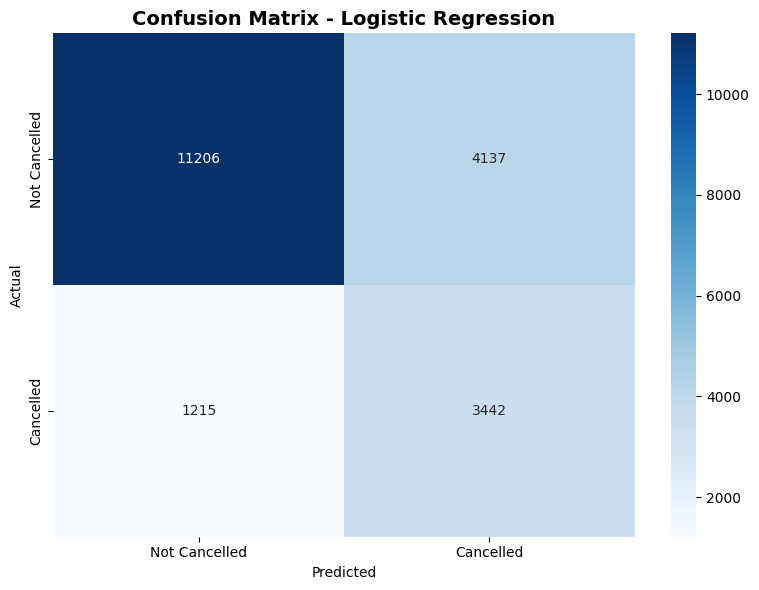


💾 Confusion matrix saved!


In [23]:
"""
Cell 20: Model 3.1 - Logistic Regression (Baseline)
"""

print("\n📈 MODEL 3.1: LOGISTIC REGRESSION")
print("="*70)

from sklearn.linear_model import LogisticRegression
import time

# Train Logistic Regression
print("\n🔧 Training Logistic Regression...")

start_time = time.time()

lr_cancel = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

lr_cancel.fit(X_train_cancel_scaled, y_train_cancel)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_lr_cancel = lr_cancel.predict(X_test_cancel_scaled)
y_pred_proba_lr_cancel = lr_cancel.predict_proba(X_test_cancel_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

# Accuracy
accuracy_lr_cancel = accuracy_score(y_test_cancel, y_pred_lr_cancel)
print(f"Accuracy: {accuracy_lr_cancel:.4f} ({accuracy_lr_cancel*100:.2f}%)")

# Precision, Recall, F1 (focus on minority class - cancelled)
precision_lr_cancel = precision_score(y_test_cancel, y_pred_lr_cancel, average='weighted', zero_division=0)
recall_lr_cancel = recall_score(y_test_cancel, y_pred_lr_cancel, average='weighted', zero_division=0)
f1_lr_cancel = f1_score(y_test_cancel, y_pred_lr_cancel, average='weighted', zero_division=0)

print(f"Precision (weighted): {precision_lr_cancel:.4f}")
print(f"Recall (weighted): {recall_lr_cancel:.4f}")
print(f"F1-Score (weighted): {f1_lr_cancel:.4f}")

# AUC
try:
    auc_lr_cancel = roc_auc_score(y_test_cancel, y_pred_proba_lr_cancel[:, 1])
    print(f"AUC: {auc_lr_cancel:.4f}")
except:
    auc_lr_cancel = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
target_names = ['Not Cancelled', 'Cancelled']
print(classification_report(y_test_cancel, y_pred_lr_cancel, target_names=target_names, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_lr_cancel = confusion_matrix(y_test_cancel, y_pred_lr_cancel)
print(cm_lr_cancel)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_cancel, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model3_lr_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model3_results = {
    'Logistic Regression': {
        'model': lr_cancel,
        'accuracy': accuracy_lr_cancel,
        'precision': precision_lr_cancel,
        'recall': recall_lr_cancel,
        'f1': f1_lr_cancel,
        'auc': auc_lr_cancel,
        'training_time': training_time,
        'predictions': y_pred_lr_cancel
    }
}

print("="*70)


🌲 MODEL 3.2: RANDOM FOREST CLASSIFIER

🔧 Training Random Forest Classifier...
   ✅ Training completed in 53.21 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.9165 (91.66%)
Precision (weighted): 0.9219
Recall (weighted): 0.9165
F1-Score (weighted): 0.9182
AUC: 0.9648

📋 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

Not Cancelled       0.96      0.93      0.94     15343
    Cancelled       0.78      0.89      0.83      4657

     accuracy                           0.92     20000
    macro avg       0.87      0.91      0.89     20000
 weighted avg       0.92      0.92      0.92     20000


🔍 CONFUSION MATRIX:
[[14209  1134]
 [  535  4122]]


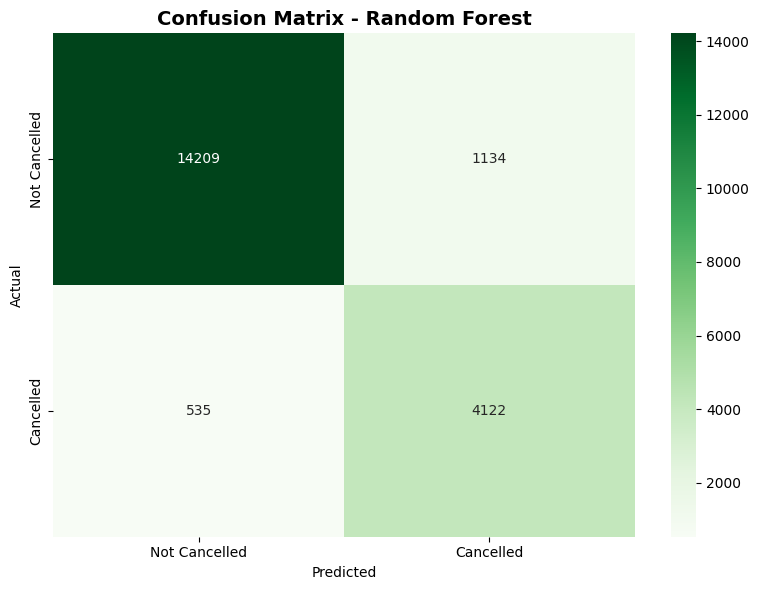


💾 Confusion matrix saved!

🌟 TOP 10 FEATURE IMPORTANCE:
                  feature  importance
     actual_ride_time_min       0.408
    pairing_quality_score       0.041
         surge_multiplier       0.041
       cust_loyalty_score       0.020
bad_weather_newbie_driver       0.020
 driver_reliability_score       0.020
        weather_condition       0.019
   driver_acceptance_rate       0.018
  estimated_ride_time_min       0.018
         weather_severity       0.018


In [24]:
"""
Cell 21: Model 3.2 - Random Forest Classifier
"""

print("\n🌲 MODEL 3.2: RANDOM FOREST CLASSIFIER")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest with regularization
print("\n🔧 Training Random Forest Classifier...")

start_time = time.time()

rf_cancel = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_cancel.fit(X_train_cancel_scaled, y_train_cancel)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_rf_cancel = rf_cancel.predict(X_test_cancel_scaled)
y_pred_proba_rf_cancel = rf_cancel.predict_proba(X_test_cancel_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_rf_cancel = accuracy_score(y_test_cancel, y_pred_rf_cancel)
precision_rf_cancel = precision_score(y_test_cancel, y_pred_rf_cancel, average='weighted', zero_division=0)
recall_rf_cancel = recall_score(y_test_cancel, y_pred_rf_cancel, average='weighted', zero_division=0)
f1_rf_cancel = f1_score(y_test_cancel, y_pred_rf_cancel, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_rf_cancel:.4f} ({accuracy_rf_cancel*100:.2f}%)")
print(f"Precision (weighted): {precision_rf_cancel:.4f}")
print(f"Recall (weighted): {recall_rf_cancel:.4f}")
print(f"F1-Score (weighted): {f1_rf_cancel:.4f}")

try:
    auc_rf_cancel = roc_auc_score(y_test_cancel, y_pred_proba_rf_cancel[:, 1])
    print(f"AUC: {auc_rf_cancel:.4f}")
except:
    auc_rf_cancel = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test_cancel, y_pred_rf_cancel, target_names=target_names, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_rf_cancel = confusion_matrix(y_test_cancel, y_pred_rf_cancel)
print(cm_rf_cancel)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_cancel, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model3_rf_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Feature Importance
print(f"\n🌟 TOP 10 FEATURE IMPORTANCE:")
print("="*70)

feature_importance_m3 = pd.DataFrame({
    'feature': X_cancel.columns,
    'importance': rf_cancel.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_m3.head(10).to_string(index=False))

# Store results
model3_results['Random Forest'] = {
    'model': rf_cancel,
    'accuracy': accuracy_rf_cancel,
    'precision': precision_rf_cancel,
    'recall': recall_rf_cancel,
    'f1': f1_rf_cancel,
    'auc': auc_rf_cancel,
    'training_time': training_time,
    'predictions': y_pred_rf_cancel,
    'feature_importance': feature_importance_m3
}

print("="*70)


⚡ MODEL 3.3: XGBOOST CLASSIFIER

   Class imbalance: 3.29:1
   Using scale_pos_weight: 3.29

🔧 Training XGBoost Classifier...
   ✅ Training completed in 4.99 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.9252 (92.52%)
Precision (weighted): 0.9418
Recall (weighted): 0.9252
F1-Score (weighted): 0.9283
AUC: 0.9837

📋 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

Not Cancelled       1.00      0.91      0.95     15343
    Cancelled       0.76      0.99      0.86      4657

     accuracy                           0.93     20000
    macro avg       0.88      0.95      0.90     20000
 weighted avg       0.94      0.93      0.93     20000


🔍 CONFUSION MATRIX:
[[13889  1454]
 [   43  4614]]


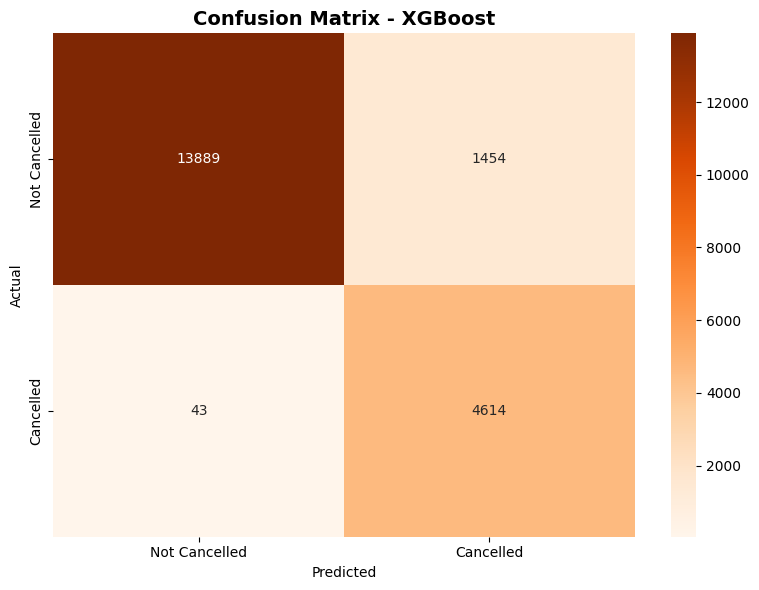


💾 Confusion matrix saved!


In [25]:
"""
Cell 22: Model 3.3 - XGBoost Classifier
"""

print("\n⚡ MODEL 3.3: XGBOOST CLASSIFIER")
print("="*70)

from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
neg_count = (y_train_cancel == 0).sum()
pos_count = (y_train_cancel == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

print(f"\n   Class imbalance: {scale_pos_weight:.2f}:1")
print(f"   Using scale_pos_weight: {scale_pos_weight:.2f}")

print("\n🔧 Training XGBoost Classifier...")

start_time = time.time()

xgb_cancel = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_cancel.fit(X_train_cancel_scaled, y_train_cancel)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_xgb_cancel = xgb_cancel.predict(X_test_cancel_scaled)
y_pred_proba_xgb_cancel = xgb_cancel.predict_proba(X_test_cancel_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_xgb_cancel = accuracy_score(y_test_cancel, y_pred_xgb_cancel)
precision_xgb_cancel = precision_score(y_test_cancel, y_pred_xgb_cancel, average='weighted', zero_division=0)
recall_xgb_cancel = recall_score(y_test_cancel, y_pred_xgb_cancel, average='weighted', zero_division=0)
f1_xgb_cancel = f1_score(y_test_cancel, y_pred_xgb_cancel, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_xgb_cancel:.4f} ({accuracy_xgb_cancel*100:.2f}%)")
print(f"Precision (weighted): {precision_xgb_cancel:.4f}")
print(f"Recall (weighted): {recall_xgb_cancel:.4f}")
print(f"F1-Score (weighted): {f1_xgb_cancel:.4f}")

try:
    auc_xgb_cancel = roc_auc_score(y_test_cancel, y_pred_proba_xgb_cancel[:, 1])
    print(f"AUC: {auc_xgb_cancel:.4f}")
except:
    auc_xgb_cancel = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test_cancel, y_pred_xgb_cancel, target_names=target_names, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_xgb_cancel = confusion_matrix(y_test_cancel, y_pred_xgb_cancel)
print(cm_xgb_cancel)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_cancel, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model3_xgb_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model3_results['XGBoost'] = {
    'model': xgb_cancel,
    'accuracy': accuracy_xgb_cancel,
    'precision': precision_xgb_cancel,
    'recall': recall_xgb_cancel,
    'f1': f1_xgb_cancel,
    'auc': auc_xgb_cancel,
    'training_time': training_time,
    'predictions': y_pred_xgb_cancel
}

print("="*70)


💡 MODEL 3.4: LIGHTGBM CLASSIFIER

   Class imbalance: 3.29:1

🔧 Training LightGBM Classifier...
   ✅ Training completed in 30.47 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.9271 (92.71%)
Precision (weighted): 0.9428
Recall (weighted): 0.9271
F1-Score (weighted): 0.9301
AUC: 0.9841

📋 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

Not Cancelled       1.00      0.91      0.95     15343
    Cancelled       0.77      0.99      0.86      4657

     accuracy                           0.93     20000
    macro avg       0.88      0.95      0.91     20000
 weighted avg       0.94      0.93      0.93     20000


🔍 CONFUSION MATRIX:
[[13934  1409]
 [   49  4608]]


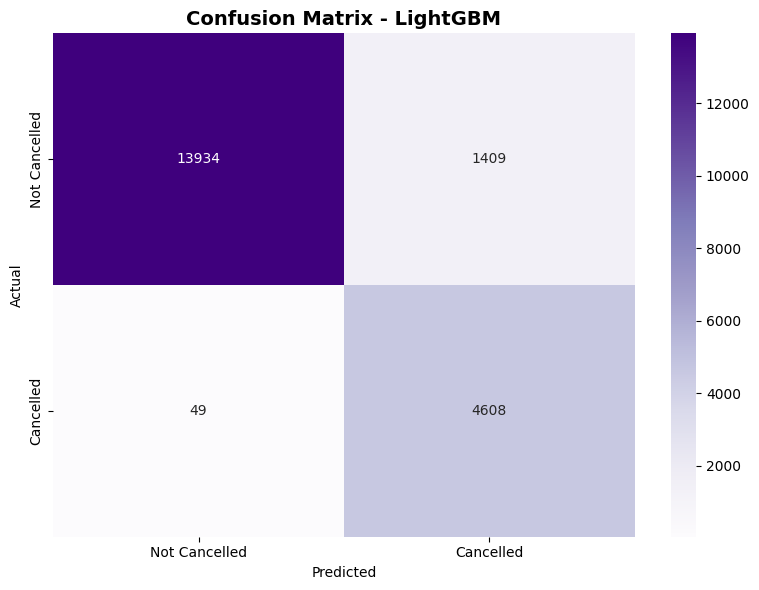


💾 Confusion matrix saved!


In [37]:
"""
Cell 22.5: Model 3.4 - LightGBM Classifier
"""

print("\n💡 MODEL 3.4: LIGHTGBM CLASSIFIER")
print("="*70)

from lightgbm import LGBMClassifier

# Calculate scale_pos_weight
neg_count = (y_train_cancel == 0).sum()
pos_count = (y_train_cancel == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

print(f"\n   Class imbalance: {scale_pos_weight:.2f}:1")

print("\n🔧 Training LightGBM Classifier...")

start_time = time.time()

lgbm_cancel = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=-1
)

lgbm_cancel.fit(X_train_cancel_scaled, y_train_cancel)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_lgbm_cancel = lgbm_cancel.predict(X_test_cancel_scaled)
y_pred_proba_lgbm_cancel = lgbm_cancel.predict_proba(X_test_cancel_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_lgbm_cancel = accuracy_score(y_test_cancel, y_pred_lgbm_cancel)
precision_lgbm_cancel = precision_score(y_test_cancel, y_pred_lgbm_cancel, average='weighted', zero_division=0)
recall_lgbm_cancel = recall_score(y_test_cancel, y_pred_lgbm_cancel, average='weighted', zero_division=0)
f1_lgbm_cancel = f1_score(y_test_cancel, y_pred_lgbm_cancel, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_lgbm_cancel:.4f} ({accuracy_lgbm_cancel*100:.2f}%)")
print(f"Precision (weighted): {precision_lgbm_cancel:.4f}")
print(f"Recall (weighted): {recall_lgbm_cancel:.4f}")
print(f"F1-Score (weighted): {f1_lgbm_cancel:.4f}")

try:
    auc_lgbm_cancel = roc_auc_score(y_test_cancel, y_pred_proba_lgbm_cancel[:, 1])
    print(f"AUC: {auc_lgbm_cancel:.4f}")
except:
    auc_lgbm_cancel = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test_cancel, y_pred_lgbm_cancel, target_names=target_names, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_lgbm_cancel = confusion_matrix(y_test_cancel, y_pred_lgbm_cancel)
print(cm_lgbm_cancel)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm_cancel, annot=True, fmt='d', cmap='Purples', cbar=True,
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - LightGBM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model3_lgbm_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model3_results['LightGBM'] = {
    'model': lgbm_cancel,
    'accuracy': accuracy_lgbm_cancel,
    'precision': precision_lgbm_cancel,
    'recall': recall_lgbm_cancel,
    'f1': f1_lgbm_cancel,
    'auc': auc_lgbm_cancel,
    'training_time': training_time,
    'predictions': y_pred_lgbm_cancel
}

print("="*70)


📊 MODEL 3: ALGORITHM COMPARISON

📋 PERFORMANCE COMPARISON:
          Algorithm  Accuracy  Precision  Recall  F1-Score   AUC  Training Time (s)
           LightGBM     0.927      0.943   0.927     0.930 0.984             30.467
            XGBoost     0.925      0.942   0.925     0.928 0.984              4.987
      Random Forest     0.917      0.922   0.917     0.918 0.965             53.210
Logistic Regression     0.732      0.798   0.732     0.750 0.814             11.324


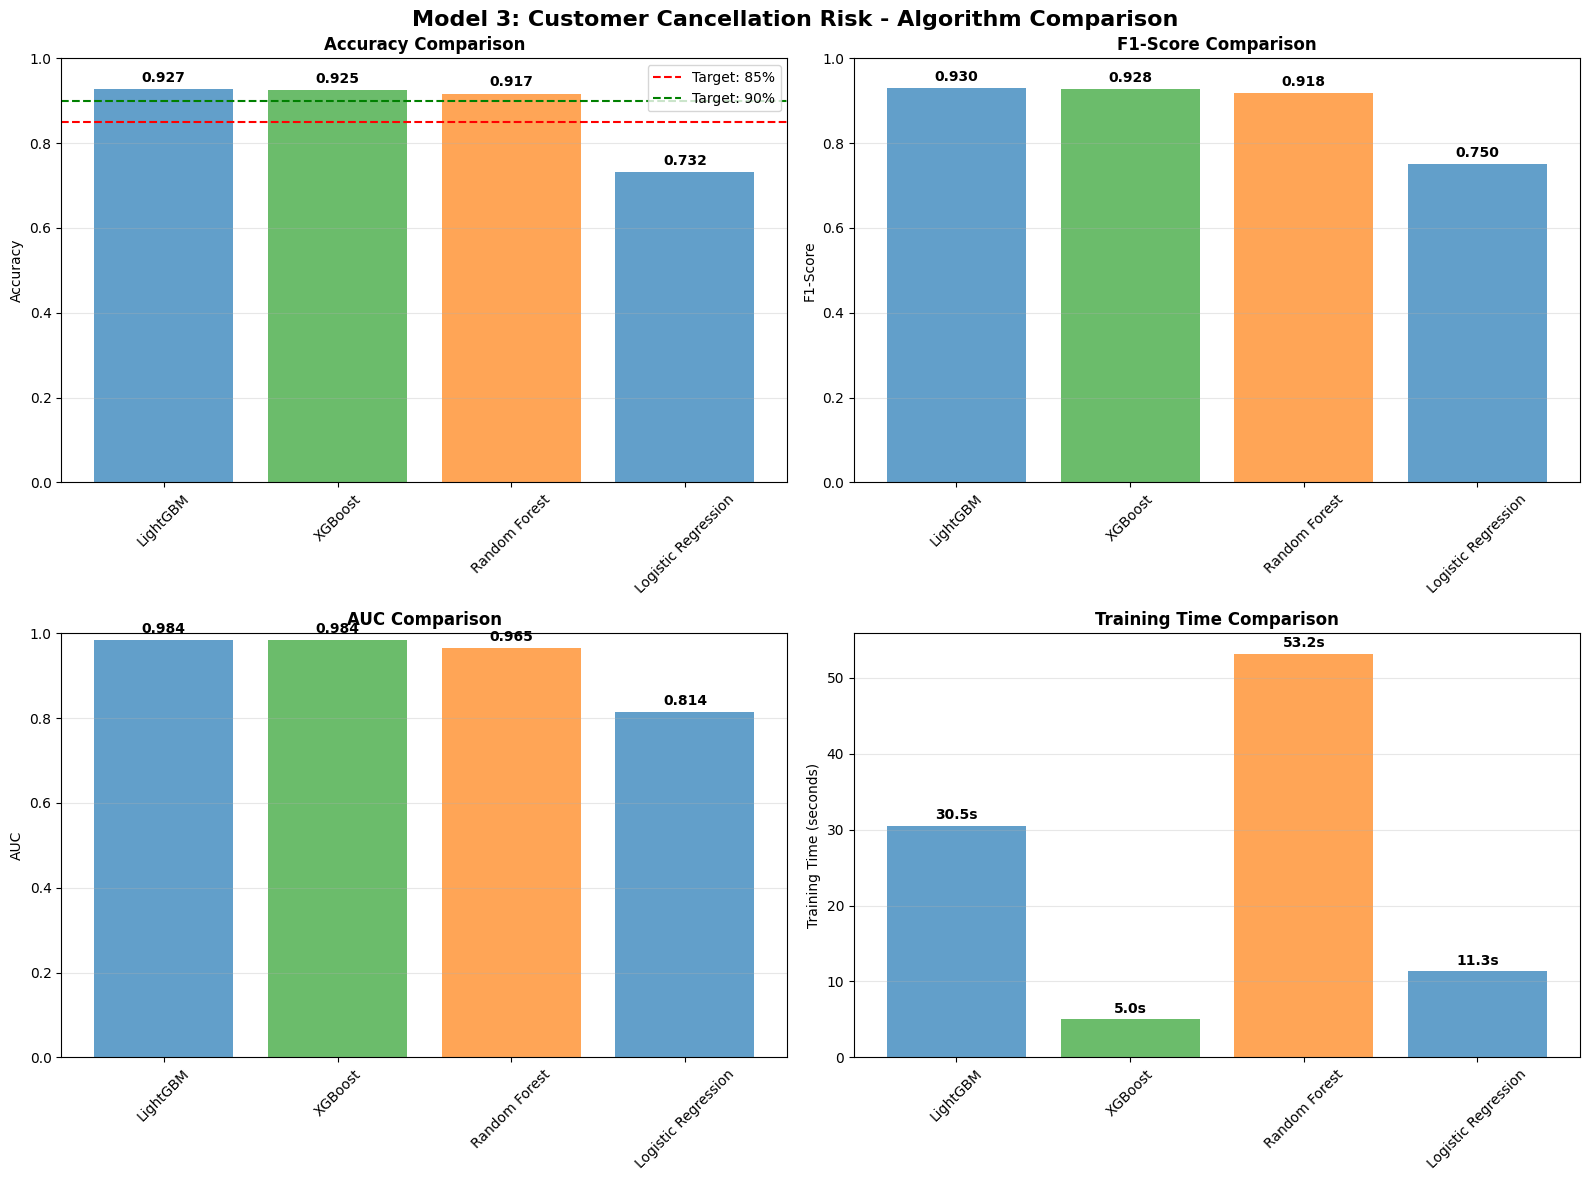


💾 Comparison chart saved!

🏆 BEST MODEL:
   Algorithm: LightGBM
   Accuracy: 0.9271 (92.71%)
   ✅ MEETS PDF BENCHMARK (≥85%)
   🌟 EXCEEDS TARGET (≥90%)


In [38]:
"""
Cell 23: Model 3 - Compare All Algorithms
"""

print("\n📊 MODEL 3: ALGORITHM COMPARISON")
print("="*70)

# Create comparison dataframe
comparison_data_m3 = []

for model_name, results in model3_results.items():
    comparison_data_m3.append({
        'Algorithm': model_name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'AUC': results['auc'] if results['auc'] else 0,
        'Training Time (s)': results['training_time']
    })

comparison_df_m3 = pd.DataFrame(comparison_data_m3)
comparison_df_m3 = comparison_df_m3.sort_values('Accuracy', ascending=False)

print("\n📋 PERFORMANCE COMPARISON:")
print("="*70)
print(comparison_df_m3.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model 3: Customer Cancellation Risk - Algorithm Comparison',
             fontsize=16, fontweight='bold')

# Accuracy comparison
axes[0, 0].bar(comparison_df_m3['Algorithm'], comparison_df_m3['Accuracy'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7)
axes[0, 0].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].axhline(y=0.85, color='r', linestyle='--', label='Target: 85%')
axes[0, 0].axhline(y=0.90, color='g', linestyle='--', label='Target: 90%')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m3['Accuracy'].values):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# F1-Score comparison
axes[0, 1].bar(comparison_df_m3['Algorithm'], comparison_df_m3['F1-Score'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7)
axes[0, 1].set_title('F1-Score Comparison', fontweight='bold')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m3['F1-Score'].values):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# AUC comparison
axes[1, 0].bar(comparison_df_m3['Algorithm'], comparison_df_m3['AUC'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7)
axes[1, 0].set_title('AUC Comparison', fontweight='bold')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m3['AUC'].values):
    if v > 0:
        axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Training time comparison
axes[1, 1].bar(comparison_df_m3['Algorithm'], comparison_df_m3['Training Time (s)'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.7)
axes[1, 1].set_title('Training Time Comparison', fontweight='bold')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m3['Training Time (s)'].values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model3_algorithm_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Comparison chart saved!")

# Identify best model
best_model_name_m3 = comparison_df_m3.iloc[0]['Algorithm']
best_accuracy_m3 = comparison_df_m3.iloc[0]['Accuracy']

print(f"\n🏆 BEST MODEL:")
print("="*70)
print(f"   Algorithm: {best_model_name_m3}")
print(f"   Accuracy: {best_accuracy_m3:.4f} ({best_accuracy_m3*100:.2f}%)")

# Check if meets PDF benchmark (85-90%)
if best_accuracy_m3 >= 0.85:
    print(f"   ✅ MEETS PDF BENCHMARK (≥85%)")
    if best_accuracy_m3 >= 0.90:
        print(f"   🌟 EXCEEDS TARGET (≥90%)")
else:
    print(f"   ⚠️ BELOW TARGET (<85%)")

print("="*70)

In [39]:
"""
Cell 24: Save Best Model for Model 3
"""

print("\n💾 SAVING MODEL 3 - BEST MODEL")
print("="*70)

# Get best model
best_model_name_m3 = comparison_df_m3.iloc[0]['Algorithm']
best_model_obj_m3 = model3_results[best_model_name_m3]['model']

# Save model
model3_save_path = os.path.join(MODEL_PATH, 'model3_customer_cancellation_best.pkl')

with open(model3_save_path, 'wb') as f:
    pickle.dump(best_model_obj_m3, f)

print(f"\n✅ Best model saved:")
print(f"   Model: {best_model_name_m3}")
print(f"   Path: {model3_save_path}")

# Save scaler
scaler_m3_save_path = os.path.join(MODEL_PATH, 'model3_scaler.pkl')
with open(scaler_m3_save_path, 'wb') as f:
    pickle.dump(scaler_m3, f)

print(f"   Scaler saved: model3_scaler.pkl")

# Save feature list
feature_list_m3_path = os.path.join(MODEL_PATH, 'model3_features.pkl')
with open(feature_list_m3_path, 'wb') as f:
    pickle.dump(X_cancel.columns.tolist(), f)

print(f"   Features saved: model3_features.pkl")

# Save label encoders
if label_encoders_m3:
    le_m3_save_path = os.path.join(MODEL_PATH, 'model3_label_encoders.pkl')
    with open(le_m3_save_path, 'wb') as f:
        pickle.dump(label_encoders_m3, f)
    print(f"   Label encoders saved: model3_label_encoders.pkl")

# Save comparison results
comparison_df_m3.to_csv(os.path.join(MODEL_PATH, 'model3_comparison.csv'), index=False)
print(f"   Comparison saved: model3_comparison.csv")

# Save feature importance if available
if 'feature_importance' in model3_results[best_model_name_m3]:
    feature_imp_path = os.path.join(MODEL_PATH, 'model3_feature_importance.csv')
    model3_results[best_model_name_m3]['feature_importance'].to_csv(feature_imp_path, index=False)
    print(f"   Feature importance saved: model3_feature_importance.csv")

print(f"\n✅ MODEL 3 COMPLETE!")
print("="*70)

# Summary
print(f"\n📊 MODEL 3 SUMMARY:")
print("="*70)
print(f"Problem: Customer Cancellation Risk (Binary Classification)")
print(f"Target: Will customer cancel? (0/1)")
print(f"Samples: {len(df_cancel):,}")
print(f"Features: {X_cancel.shape[1]}")
print(f"Algorithms Tested: {len(model3_results)}")
print(f"Best Algorithm: {best_model_name_m3}")
print(f"Best Accuracy: {comparison_df_m3.iloc[0]['Accuracy']:.4f} ({comparison_df_m3.iloc[0]['Accuracy']*100:.2f}%)")
print(f"Best AUC: {comparison_df_m3.iloc[0]['AUC']:.4f}")
print(f"PDF Benchmark: {'✅ ACHIEVED' if comparison_df_m3.iloc[0]['Accuracy'] >= 0.85 else '⚠️ NEEDS IMPROVEMENT'}")
print("="*70)


💾 SAVING MODEL 3 - BEST MODEL

✅ Best model saved:
   Model: LightGBM
   Path: /content/drive/MyDrive/Rapido_Project/models/model3_customer_cancellation_best.pkl
   Scaler saved: model3_scaler.pkl
   Features saved: model3_features.pkl
   Label encoders saved: model3_label_encoders.pkl
   Comparison saved: model3_comparison.csv

✅ MODEL 3 COMPLETE!

📊 MODEL 3 SUMMARY:
Problem: Customer Cancellation Risk (Binary Classification)
Target: Will customer cancel? (0/1)
Samples: 100,000
Features: 133
Algorithms Tested: 4
Best Algorithm: LightGBM
Best Accuracy: 0.9271 (92.71%)
Best AUC: 0.9841
PDF Benchmark: ✅ ACHIEVED


#📊 MODEL 4: DRIVER DELAY PREDICTION (BINARY CLASSIFICATION)
## This model predicts whether a driver is likely to cause delays or incomplete rides based on past delay history, traffic exposure, and acceptance behavior.


In [32]:
"""
Cell 25: Prepare Data for Model 4 - Driver Delay Prediction (Binary Classification) - FIXED
Target: Will driver be delayed? (0 = No, 1 = Yes)
"""

print("="*70)
print("MODEL 4: DRIVER DELAY PREDICTION (BINARY CLASSIFICATION)")
print("="*70)

# Check if target exists
target_col = 'target_driver_delayed'

# If not found, try alternative column names
if target_col not in df.columns:
    print(f"⚠️ {target_col} not found! Checking alternatives...")

    # Try common delay-related columns
    delay_candidates = [col for col in df.columns if 'delay' in col.lower() and ('driver' in col.lower() or 'flag' in col.lower())]

    if delay_candidates:
        source_col = delay_candidates[0]
        print(f"   Found potential column: '{source_col}'")

        # Check unique values
        unique_vals = df[source_col].dropna().unique()
        print(f"   Unique values in {source_col}: {sorted(unique_vals)[:10]}")

        # Convert to binary (0/1)
        if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1}):
            df['target_driver_delayed'] = df[source_col]
            print(f"   ✅ Using {source_col} directly (already binary)")
        else:
            # Convert any non-zero value to 1
            df['target_driver_delayed'] = (df[source_col] > 0).astype(int)
            print(f"   ✅ Converted {source_col} to binary (any delay > 0 = 1)")

        target_col = 'target_driver_delayed'
    else:
        # Create from driver_delay_flag or driver_delay_rate
        if 'driver_delay_flag' in df.columns:
            unique_vals = df['driver_delay_flag'].dropna().unique()
            print(f"   Using driver_delay_flag. Unique values: {sorted(unique_vals)[:10]}")
            df['target_driver_delayed'] = (df['driver_delay_flag'] > 0).astype(int)
            target_col = 'target_driver_delayed'
            print(f"   ✅ Created target_driver_delayed from driver_delay_flag")
        elif 'driver_delay_rate' in df.columns:
            df['target_driver_delayed'] = (df['driver_delay_rate'] > 0.2).astype(int)
            target_col = 'target_driver_delayed'
            print(f"   ✅ Created target_driver_delayed from driver_delay_rate (threshold: 20%)")
        elif 'driver_delay_count' in df.columns:
            df['target_driver_delayed'] = (df['driver_delay_count'] > 0).astype(int)
            target_col = 'target_driver_delayed'
            print(f"   ✅ Created target_driver_delayed from driver_delay_count")
        else:
            print(f"   ❌ ERROR: Cannot create driver delay target!")
            print(f"   Available delay-related columns: {[col for col in df.columns if 'delay' in col.lower()]}")
            raise ValueError("Cannot find or create driver delay target")
else:
    # Target exists but might not be binary
    unique_vals = df[target_col].dropna().unique()
    print(f"\n🎯 Target Variable: {target_col}")
    print(f"   Unique values: {sorted(unique_vals)[:10]}")

    if len(unique_vals) > 2:
        print(f"   ⚠️ Target has {len(unique_vals)} classes, converting to binary...")
        # Convert to binary: 0 = no delay, 1 = any delay
        df[target_col] = (df[target_col] > 0).astype(int)
        print(f"   ✅ Converted to binary (0 = No Delay, 1 = Delay)")
        unique_vals = df[target_col].unique()

# Verify target is now binary
if target_col in df.columns:
    unique_vals = df[target_col].dropna().unique()

    if len(unique_vals) != 2:
        print(f"\n❌ ERROR: Target still has {len(unique_vals)} classes after conversion!")
        print(f"   Values: {sorted(unique_vals)}")
        raise ValueError(f"Target must be binary (0/1), got {len(unique_vals)} classes")

    if not set(unique_vals).issubset({0, 1}):
        print(f"\n⚠️ Converting target values to 0/1...")
        # Map to 0/1
        val_map = {sorted(unique_vals)[0]: 0, sorted(unique_vals)[1]: 1}
        df[target_col] = df[target_col].map(val_map)
        print(f"   ✅ Mapped {val_map}")

    print(f"\n🎯 Target Variable: {target_col}")
    print(f"   ✅ Binary target confirmed: {sorted(df[target_col].dropna().unique())}")

    # Create working dataframe
    df_delay = df.copy()

    # Remove rows with missing target
    original_len = len(df_delay)
    df_delay = df_delay[df_delay[target_col].notna()]
    removed = original_len - len(df_delay)

    if removed > 0:
        print(f"\n   Removed {removed:,} rows with missing target")

    print(f"   Remaining samples: {len(df_delay):,}")

    # Check class distribution
    print(f"\n📊 Class Distribution:")
    class_dist = df_delay[target_col].value_counts().sort_index()

    for cls, count in class_dist.items():
        pct = (count / len(df_delay)) * 100
        label = "No Delay" if cls == 0 else "Delayed"
        print(f"   Class {cls} ({label}): {count:,} ({pct:.2f}%)")

    # Check for class imbalance
    if len(class_dist) >= 2:
        imbalance_ratio = class_dist.max() / class_dist.min()
        print(f"\n⚖️ Imbalance Ratio: {imbalance_ratio:.2f}:1")

        if imbalance_ratio > 10:
            print(f"   ⚠️ SEVERE IMBALANCE - Will use class weights")
        elif imbalance_ratio > 3:
            print(f"   ⚠️ MODERATE IMBALANCE - Will use class weights")
        else:
            print(f"   ✅ BALANCED - No special handling needed")

    # Remove delay-related features to prevent leakage
    print(f"\n🚨 PREVENTING DATA LEAKAGE - Removing delay-related features...")

    delay_related_keywords = [
        'delay', 'delayed', 'late', 'time_delay', 'pickup_delay',
        'incomplete', 'incomplete_ride', 'is_delayed', 'avg_pickup_delay'
    ]

    # Get feature list
    original_feature_cols = feature_cols.copy()

    # Remove delay-related features
    delay_features_to_remove = []
    for col in original_feature_cols:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in delay_related_keywords):
            delay_features_to_remove.append(col)

    # Clean feature list
    feature_cols_delay = [col for col in original_feature_cols if col not in delay_features_to_remove]

    print(f"   Original features: {len(original_feature_cols)}")
    print(f"   Delay-related removed: {len(delay_features_to_remove)}")
    print(f"   Clean features: {len(feature_cols_delay)}")

    if len(delay_features_to_remove) > 0:
        print(f"\n   🗑️ Removed columns (to prevent leakage):")
        for col in delay_features_to_remove[:15]:
            print(f"      • {col}")
        if len(delay_features_to_remove) > 15:
            print(f"      ... and {len(delay_features_to_remove) - 15} more")

    # Prepare features
    print(f"\n🔧 Preparing features for classification...")

    X_delay = df_delay[feature_cols_delay].copy()
    y_delay = df_delay[target_col].copy()

    # FINAL VERIFICATION: Ensure target is binary
    unique_y = y_delay.unique()
    print(f"\n🔍 FINAL TARGET VERIFICATION:")
    print(f"   Unique values in target: {sorted(unique_y)}")
    print(f"   Number of classes: {len(unique_y)}")

    if len(unique_y) != 2:
        raise ValueError(f"Target must have exactly 2 classes, found {len(unique_y)}: {sorted(unique_y)}")

    if not set(unique_y).issubset({0, 1}):
        raise ValueError(f"Target values must be 0 and 1, found: {sorted(unique_y)}")

    print(f"   ✅ Target is valid binary (0/1)")

    # Encode categorical features
    label_encoders_m4 = {}
    categorical_features_in_X = [col for col in categorical_features if col in X_delay.columns]

    for col in categorical_features_in_X:
        le = LabelEncoder()
        X_delay[col] = X_delay[col].fillna('Unknown')
        X_delay[col] = le.fit_transform(X_delay[col].astype(str))
        label_encoders_m4[col] = le

    print(f"\n   ✅ Encoded {len(label_encoders_m4)} categorical features")

    # Check for any remaining non-numeric columns
    non_numeric = X_delay.select_dtypes(exclude=[np.number]).columns
    if len(non_numeric) > 0:
        print(f"   ⚠️ Dropping {len(non_numeric)} non-numeric columns: {list(non_numeric)}")
        X_delay = X_delay.select_dtypes(include=[np.number])

    # Final data quality check
    print(f"\n🔍 FINAL DATA QUALITY CHECK:")
    print(f"   X shape: {X_delay.shape}")
    print(f"   y shape: {y_delay.shape}")
    print(f"   X NaN count: {X_delay.isnull().sum().sum()}")
    print(f"   y NaN count: {y_delay.isnull().sum()}")

    if X_delay.isnull().sum().sum() > 0:
        X_delay = X_delay.fillna(0)
        print(f"   ✅ Replaced NaN with 0")

    if np.isinf(X_delay).sum().sum() > 0:
        X_delay = X_delay.replace([np.inf, -np.inf], 0)
        print(f"   ✅ Replaced Inf with 0")

    # Verify clean
    assert X_delay.isnull().sum().sum() == 0, "❌ Features still contain NaN!"
    assert y_delay.isnull().sum() == 0, "❌ Target still contains NaN!"

    print(f"\n   ✅ Data is clean and ready!")

    # Train-test split (80/20 as per PDF)
    print(f"\n✂️ Splitting data (80/20)...")
    X_train_delay, X_test_delay, y_train_delay, y_test_delay = train_test_split(
        X_delay, y_delay, test_size=0.2, random_state=42, stratify=y_delay
    )

    print(f"   Training set: {X_train_delay.shape[0]:,} samples")
    print(f"   Test set: {X_test_delay.shape[0]:,} samples")

    # Check class distribution in train/test
    print(f"\n   Training set distribution:")
    for cls, count in y_train_delay.value_counts().sort_index().items():
        pct = (count / len(y_train_delay)) * 100
        label = "No Delay" if cls == 0 else "Delayed"
        print(f"      Class {cls} ({label}): {count:,} ({pct:.2f}%)")

    print(f"\n   Test set distribution:")
    for cls, count in y_test_delay.value_counts().sort_index().items():
        pct = (count / len(y_test_delay)) * 100
        label = "No Delay" if cls == 0 else "Delayed"
        print(f"      Class {cls} ({label}): {count:,} ({pct:.2f}%)")

    # Scale features
    print(f"\n📏 Scaling features...")
    scaler_m4 = StandardScaler()
    X_train_delay_scaled = scaler_m4.fit_transform(X_train_delay)
    X_test_delay_scaled = scaler_m4.transform(X_test_delay)

    print(f"   ✅ Features scaled using StandardScaler")

    # Post-scaling verification
    if np.isnan(X_train_delay_scaled).sum() > 0 or np.isnan(X_test_delay_scaled).sum() > 0:
        X_train_delay_scaled = np.nan_to_num(X_train_delay_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_delay_scaled = np.nan_to_num(X_test_delay_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        print(f"   ✅ Post-scaling NaN/Inf cleaned")

    print(f"\n✅ Data preparation complete for Model 4!")

print("="*70)

MODEL 4: DRIVER DELAY PREDICTION (BINARY CLASSIFICATION)

🎯 Target Variable: target_driver_delayed
   Unique values: [np.int64(0), np.int64(1)]

🎯 Target Variable: target_driver_delayed
   ✅ Binary target confirmed: [np.int64(0), np.int64(1)]
   Remaining samples: 100,000

📊 Class Distribution:
   Class 0 (No Delay): 36,778 (36.78%)
   Class 1 (Delayed): 63,222 (63.22%)

⚖️ Imbalance Ratio: 1.72:1
   ✅ BALANCED - No special handling needed

🚨 PREVENTING DATA LEAKAGE - Removing delay-related features...
   Original features: 143
   Delay-related removed: 11
   Clean features: 132

   🗑️ Removed columns (to prevent leakage):
      • incomplete_ride_reason
      • cust_incomplete_rides
      • driver_incomplete_rides
      • driver_delay_count
      • driver_delay_rate
      • driver_avg_pickup_delay_min
      • driver_driver_delay_flag
      • is_late_night
      • driver_late_night_rides
      • driver_late_night_pct
      • long_late_night_ride

🔧 Preparing features for classification.


📈 MODEL 4.1: LOGISTIC REGRESSION

🔧 Training Logistic Regression...
   ✅ Training completed in 12.64 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.5818 (58.18%)
Precision (weighted): 0.6117
Recall (weighted): 0.5818
F1-Score (weighted): 0.5892
AUC: 0.6188

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    No Delay       0.45      0.59      0.51      7356
     Delayed       0.71      0.58      0.64     12644

    accuracy                           0.58     20000
   macro avg       0.58      0.58      0.57     20000
weighted avg       0.61      0.58      0.59     20000


🔍 CONFUSION MATRIX:
[[4326 3030]
 [5334 7310]]


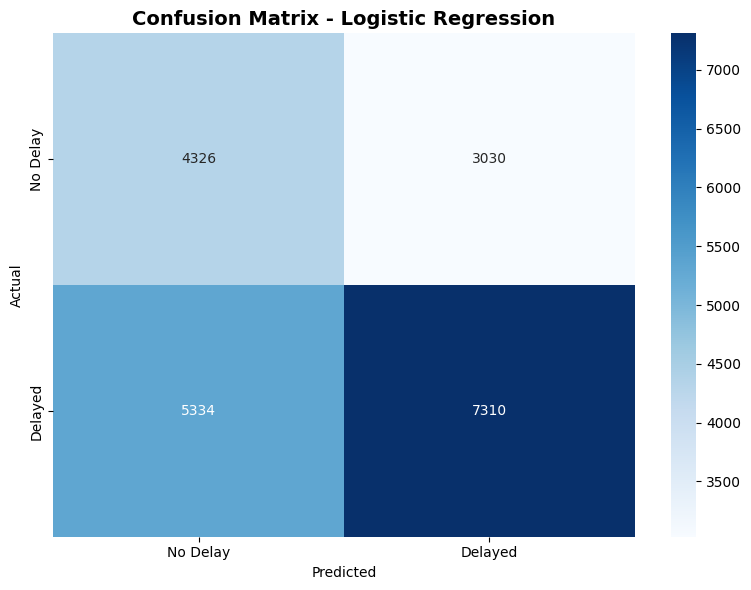


💾 Confusion matrix saved!


In [33]:
"""
Cell 26: Model 4.1 - Logistic Regression (Baseline)
"""

print("\n📈 MODEL 4.1: LOGISTIC REGRESSION")
print("="*70)

from sklearn.linear_model import LogisticRegression
import time

# Train Logistic Regression
print("\n🔧 Training Logistic Regression...")

start_time = time.time()

lr_delay = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

lr_delay.fit(X_train_delay_scaled, y_train_delay)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_lr_delay = lr_delay.predict(X_test_delay_scaled)
y_pred_proba_lr_delay = lr_delay.predict_proba(X_test_delay_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

# Accuracy
accuracy_lr_delay = accuracy_score(y_test_delay, y_pred_lr_delay)
print(f"Accuracy: {accuracy_lr_delay:.4f} ({accuracy_lr_delay*100:.2f}%)")

# Precision, Recall, F1
precision_lr_delay = precision_score(y_test_delay, y_pred_lr_delay, average='weighted', zero_division=0)
recall_lr_delay = recall_score(y_test_delay, y_pred_lr_delay, average='weighted', zero_division=0)
f1_lr_delay = f1_score(y_test_delay, y_pred_lr_delay, average='weighted', zero_division=0)

print(f"Precision (weighted): {precision_lr_delay:.4f}")
print(f"Recall (weighted): {recall_lr_delay:.4f}")
print(f"F1-Score (weighted): {f1_lr_delay:.4f}")

# AUC
try:
    auc_lr_delay = roc_auc_score(y_test_delay, y_pred_proba_lr_delay[:, 1])
    print(f"AUC: {auc_lr_delay:.4f}")
except:
    auc_lr_delay = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
target_names_delay = ['No Delay', 'Delayed']
print(classification_report(y_test_delay, y_pred_lr_delay, target_names=target_names_delay, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_lr_delay = confusion_matrix(y_test_delay, y_pred_lr_delay)
print(cm_lr_delay)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_delay, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=target_names_delay, yticklabels=target_names_delay)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model4_lr_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model4_results = {
    'Logistic Regression': {
        'model': lr_delay,
        'accuracy': accuracy_lr_delay,
        'precision': precision_lr_delay,
        'recall': recall_lr_delay,
        'f1': f1_lr_delay,
        'auc': auc_lr_delay,
        'training_time': training_time,
        'predictions': y_pred_lr_delay
    }
}

print("="*70)


🌲 MODEL 4.2: RANDOM FOREST CLASSIFIER

🔧 Training Random Forest Classifier...
   Using stronger regularization to prevent overfitting...
   ✅ Training completed in 14.59 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.6862 (68.62%)
Precision (weighted): 0.7005
Recall (weighted): 0.6862
F1-Score (weighted): 0.6905
AUC: 0.7564

🔍 OVERFITTING CHECK:
   Training Accuracy: 0.6982
   Test Accuracy: 0.6862
   Difference: 0.0120
   ✅ NO OVERFITTING (train-test gap acceptable)

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    No Delay       0.56      0.66      0.61      7356
     Delayed       0.78      0.70      0.74     12644

    accuracy                           0.69     20000
   macro avg       0.67      0.68      0.67     20000
weighted avg       0.70      0.69      0.69     20000


🔍 CONFUSION MATRIX:
[[4873 2483]
 [3793 8851]]


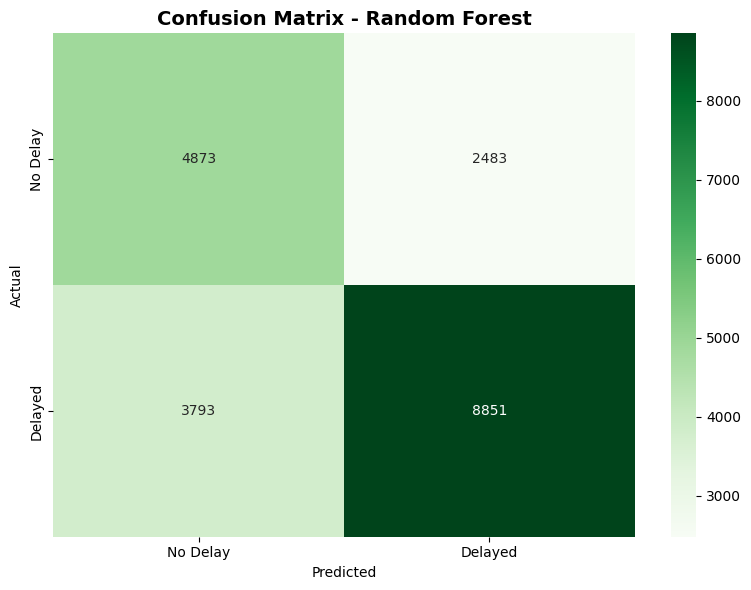


💾 Confusion matrix saved!

🌟 TOP 10 FEATURE IMPORTANCE:
                    feature  importance
      driver_accepted_rides       0.085
   driver_total_completions       0.069
       driver_total_revenue       0.062
driver_total_assigned_rides       0.056
         driver_total_rides       0.052
            driver_avg_fare       0.049
   driver_utilization_score       0.048
        driver_avg_distance       0.045
    driver_revenue_per_ride       0.043
   driver_reliability_score       0.037


In [40]:
"""
Cell 27: Model 4.2 - Random Forest Classifier (STRONGER REGULARIZATION)
"""

print("\n🌲 MODEL 4.2: RANDOM FOREST CLASSIFIER")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest with STRONGER regularization
print("\n🔧 Training Random Forest Classifier...")
print("   Using stronger regularization to prevent overfitting...")

start_time = time.time()

rf_delay = RandomForestClassifier(
    n_estimators=50,           # Reduced from 100
    max_depth=8,               # Much shallower (was 15)
    min_samples_split=20,      # Increased (was 10)
    min_samples_leaf=10,       # Increased (was 5)
    max_features='sqrt',
    max_samples=0.7,           # Use only 70% of samples per tree
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_delay.fit(X_train_delay_scaled, y_train_delay)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_rf_delay = rf_delay.predict(X_test_delay_scaled)
y_pred_proba_rf_delay = rf_delay.predict_proba(X_test_delay_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_rf_delay = accuracy_score(y_test_delay, y_pred_rf_delay)
precision_rf_delay = precision_score(y_test_delay, y_pred_rf_delay, average='weighted', zero_division=0)
recall_rf_delay = recall_score(y_test_delay, y_pred_rf_delay, average='weighted', zero_division=0)
f1_rf_delay = f1_score(y_test_delay, y_pred_rf_delay, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_rf_delay:.4f} ({accuracy_rf_delay*100:.2f}%)")
print(f"Precision (weighted): {precision_rf_delay:.4f}")
print(f"Recall (weighted): {recall_rf_delay:.4f}")
print(f"F1-Score (weighted): {f1_rf_delay:.4f}")

try:
    auc_rf_delay = roc_auc_score(y_test_delay, y_pred_proba_rf_delay[:, 1])
    print(f"AUC: {auc_rf_delay:.4f}")
except:
    auc_rf_delay = None
    print(f"AUC: Could not calculate")

# Check for overfitting
print(f"\n🔍 OVERFITTING CHECK:")
print("="*70)
y_pred_train_rf = rf_delay.predict(X_train_delay_scaled)
accuracy_train_rf = accuracy_score(y_train_delay, y_pred_train_rf)

print(f"   Training Accuracy: {accuracy_train_rf:.4f}")
print(f"   Test Accuracy: {accuracy_rf_delay:.4f}")
print(f"   Difference: {abs(accuracy_train_rf - accuracy_rf_delay):.4f}")

if abs(accuracy_train_rf - accuracy_rf_delay) > 0.1:
    print(f"   ⚠️ OVERFITTING DETECTED (train-test gap > 0.1)")
elif accuracy_rf_delay > 0.95:
    print(f"   ⚠️ SUSPICIOUSLY HIGH test accuracy (>95%)")
else:
    print(f"   ✅ NO OVERFITTING (train-test gap acceptable)")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test_delay, y_pred_rf_delay, target_names=target_names_delay, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_rf_delay = confusion_matrix(y_test_delay, y_pred_rf_delay)
print(cm_rf_delay)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_delay, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=target_names_delay, yticklabels=target_names_delay)
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model4_rf_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Feature Importance
print(f"\n🌟 TOP 10 FEATURE IMPORTANCE:")
print("="*70)

feature_importance_m4 = pd.DataFrame({
    'feature': X_delay.columns,
    'importance': rf_delay.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_m4.head(10).to_string(index=False))

# Store results
model4_results['Random Forest'] = {
    'model': rf_delay,
    'accuracy': accuracy_rf_delay,
    'precision': precision_rf_delay,
    'recall': recall_rf_delay,
    'f1': f1_rf_delay,
    'auc': auc_rf_delay,
    'training_time': training_time,
    'predictions': y_pred_rf_delay,
    'feature_importance': feature_importance_m4
}

print("="*70)


⚡ MODEL 4.3: XGBOOST CLASSIFIER

   Class imbalance: 0.58:1
   Using scale_pos_weight: 0.58

🔧 Training XGBoost Classifier...
   ✅ Training completed in 4.29 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.7937 (79.38%)
Precision (weighted): 0.8077
Recall (weighted): 0.7937
F1-Score (weighted): 0.7967
AUC: 0.8908

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    No Delay       0.68      0.82      0.74      7356
     Delayed       0.88      0.78      0.83     12644

    accuracy                           0.79     20000
   macro avg       0.78      0.80      0.79     20000
weighted avg       0.81      0.79      0.80     20000


🔍 CONFUSION MATRIX:
[[6008 1348]
 [2777 9867]]


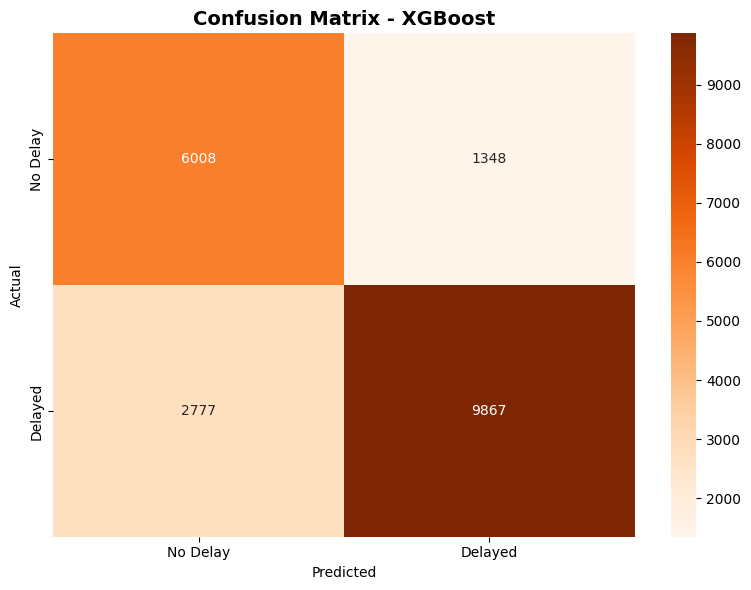


💾 Confusion matrix saved!


In [41]:
"""
Cell 28: Model 4.3 - XGBoost Classifier
"""

print("\n⚡ MODEL 4.3: XGBOOST CLASSIFIER")
print("="*70)

from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
neg_count = (y_train_delay == 0).sum()
pos_count = (y_train_delay == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

print(f"\n   Class imbalance: {scale_pos_weight:.2f}:1")
print(f"   Using scale_pos_weight: {scale_pos_weight:.2f}")

print("\n🔧 Training XGBoost Classifier...")

start_time = time.time()

xgb_delay = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_delay.fit(X_train_delay_scaled, y_train_delay)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_xgb_delay = xgb_delay.predict(X_test_delay_scaled)
y_pred_proba_xgb_delay = xgb_delay.predict_proba(X_test_delay_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_xgb_delay = accuracy_score(y_test_delay, y_pred_xgb_delay)
precision_xgb_delay = precision_score(y_test_delay, y_pred_xgb_delay, average='weighted', zero_division=0)
recall_xgb_delay = recall_score(y_test_delay, y_pred_xgb_delay, average='weighted', zero_division=0)
f1_xgb_delay = f1_score(y_test_delay, y_pred_xgb_delay, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_xgb_delay:.4f} ({accuracy_xgb_delay*100:.2f}%)")
print(f"Precision (weighted): {precision_xgb_delay:.4f}")
print(f"Recall (weighted): {recall_xgb_delay:.4f}")
print(f"F1-Score (weighted): {f1_xgb_delay:.4f}")

try:
    auc_xgb_delay = roc_auc_score(y_test_delay, y_pred_proba_xgb_delay[:, 1])
    print(f"AUC: {auc_xgb_delay:.4f}")
except:
    auc_xgb_delay = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test_delay, y_pred_xgb_delay, target_names=target_names_delay, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_xgb_delay = confusion_matrix(y_test_delay, y_pred_xgb_delay)
print(cm_xgb_delay)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_delay, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=target_names_delay, yticklabels=target_names_delay)
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model4_xgb_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model4_results['XGBoost'] = {
    'model': xgb_delay,
    'accuracy': accuracy_xgb_delay,
    'precision': precision_xgb_delay,
    'recall': recall_xgb_delay,
    'f1': f1_xgb_delay,
    'auc': auc_xgb_delay,
    'training_time': training_time,
    'predictions': y_pred_xgb_delay
}

print("="*70)


💡 MODEL 4.4: LIGHTGBM CLASSIFIER

   Class imbalance: 0.58:1

🔧 Training LightGBM Classifier...
   ✅ Training completed in 5.24 seconds

📊 Making predictions...

📈 EVALUATION METRICS:
Accuracy: 0.8304 (83.04%)
Precision (weighted): 0.8450
Recall (weighted): 0.8304
F1-Score (weighted): 0.8329
AUC: 0.9239

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    No Delay       0.72      0.87      0.79      7356
     Delayed       0.92      0.81      0.86     12644

    accuracy                           0.83     20000
   macro avg       0.82      0.84      0.82     20000
weighted avg       0.85      0.83      0.83     20000


🔍 CONFUSION MATRIX:
[[ 6419   937]
 [ 2455 10189]]


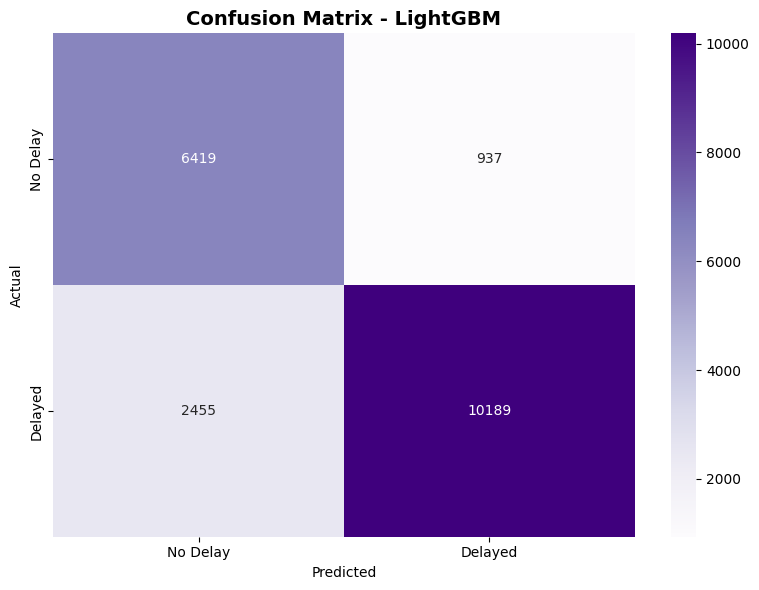


💾 Confusion matrix saved!


In [42]:
"""
Cell 29: Model 4.4 - LightGBM Classifier
"""

print("\n💡 MODEL 4.4: LIGHTGBM CLASSIFIER")
print("="*70)

from lightgbm import LGBMClassifier

# Calculate scale_pos_weight
neg_count = (y_train_delay == 0).sum()
pos_count = (y_train_delay == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

print(f"\n   Class imbalance: {scale_pos_weight:.2f}:1")

print("\n🔧 Training LightGBM Classifier...")

start_time = time.time()

lgbm_delay = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=-1
)

lgbm_delay.fit(X_train_delay_scaled, y_train_delay)

training_time = time.time() - start_time

print(f"   ✅ Training completed in {training_time:.2f} seconds")

# Make predictions
print(f"\n📊 Making predictions...")
y_pred_lgbm_delay = lgbm_delay.predict(X_test_delay_scaled)
y_pred_proba_lgbm_delay = lgbm_delay.predict_proba(X_test_delay_scaled)

# Evaluate
print(f"\n📈 EVALUATION METRICS:")
print("="*70)

accuracy_lgbm_delay = accuracy_score(y_test_delay, y_pred_lgbm_delay)
precision_lgbm_delay = precision_score(y_test_delay, y_pred_lgbm_delay, average='weighted', zero_division=0)
recall_lgbm_delay = recall_score(y_test_delay, y_pred_lgbm_delay, average='weighted', zero_division=0)
f1_lgbm_delay = f1_score(y_test_delay, y_pred_lgbm_delay, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy_lgbm_delay:.4f} ({accuracy_lgbm_delay*100:.2f}%)")
print(f"Precision (weighted): {precision_lgbm_delay:.4f}")
print(f"Recall (weighted): {recall_lgbm_delay:.4f}")
print(f"F1-Score (weighted): {f1_lgbm_delay:.4f}")

try:
    auc_lgbm_delay = roc_auc_score(y_test_delay, y_pred_proba_lgbm_delay[:, 1])
    print(f"AUC: {auc_lgbm_delay:.4f}")
except:
    auc_lgbm_delay = None
    print(f"AUC: Could not calculate")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print("="*70)
print(classification_report(y_test_delay, y_pred_lgbm_delay, target_names=target_names_delay, zero_division=0))

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
print("="*70)
cm_lgbm_delay = confusion_matrix(y_test_delay, y_pred_lgbm_delay)
print(cm_lgbm_delay)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm_delay, annot=True, fmt='d', cmap='Purples', cbar=True,
            xticklabels=target_names_delay, yticklabels=target_names_delay)
plt.title('Confusion Matrix - LightGBM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model4_lgbm_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrix saved!")

# Store results
model4_results['LightGBM'] = {
    'model': lgbm_delay,
    'accuracy': accuracy_lgbm_delay,
    'precision': precision_lgbm_delay,
    'recall': recall_lgbm_delay,
    'f1': f1_lgbm_delay,
    'auc': auc_lgbm_delay,
    'training_time': training_time,
    'predictions': y_pred_lgbm_delay
}

print("="*70)


📊 MODEL 4: ALGORITHM COMPARISON

📋 PERFORMANCE COMPARISON:
          Algorithm  Accuracy  Precision  Recall  F1-Score   AUC  Training Time (s)
           LightGBM     0.830      0.845   0.830     0.833 0.924              5.240
            XGBoost     0.794      0.808   0.794     0.797 0.891              4.295
      Random Forest     0.686      0.701   0.686     0.690 0.756             14.585
Logistic Regression     0.582      0.612   0.582     0.589 0.619             12.637


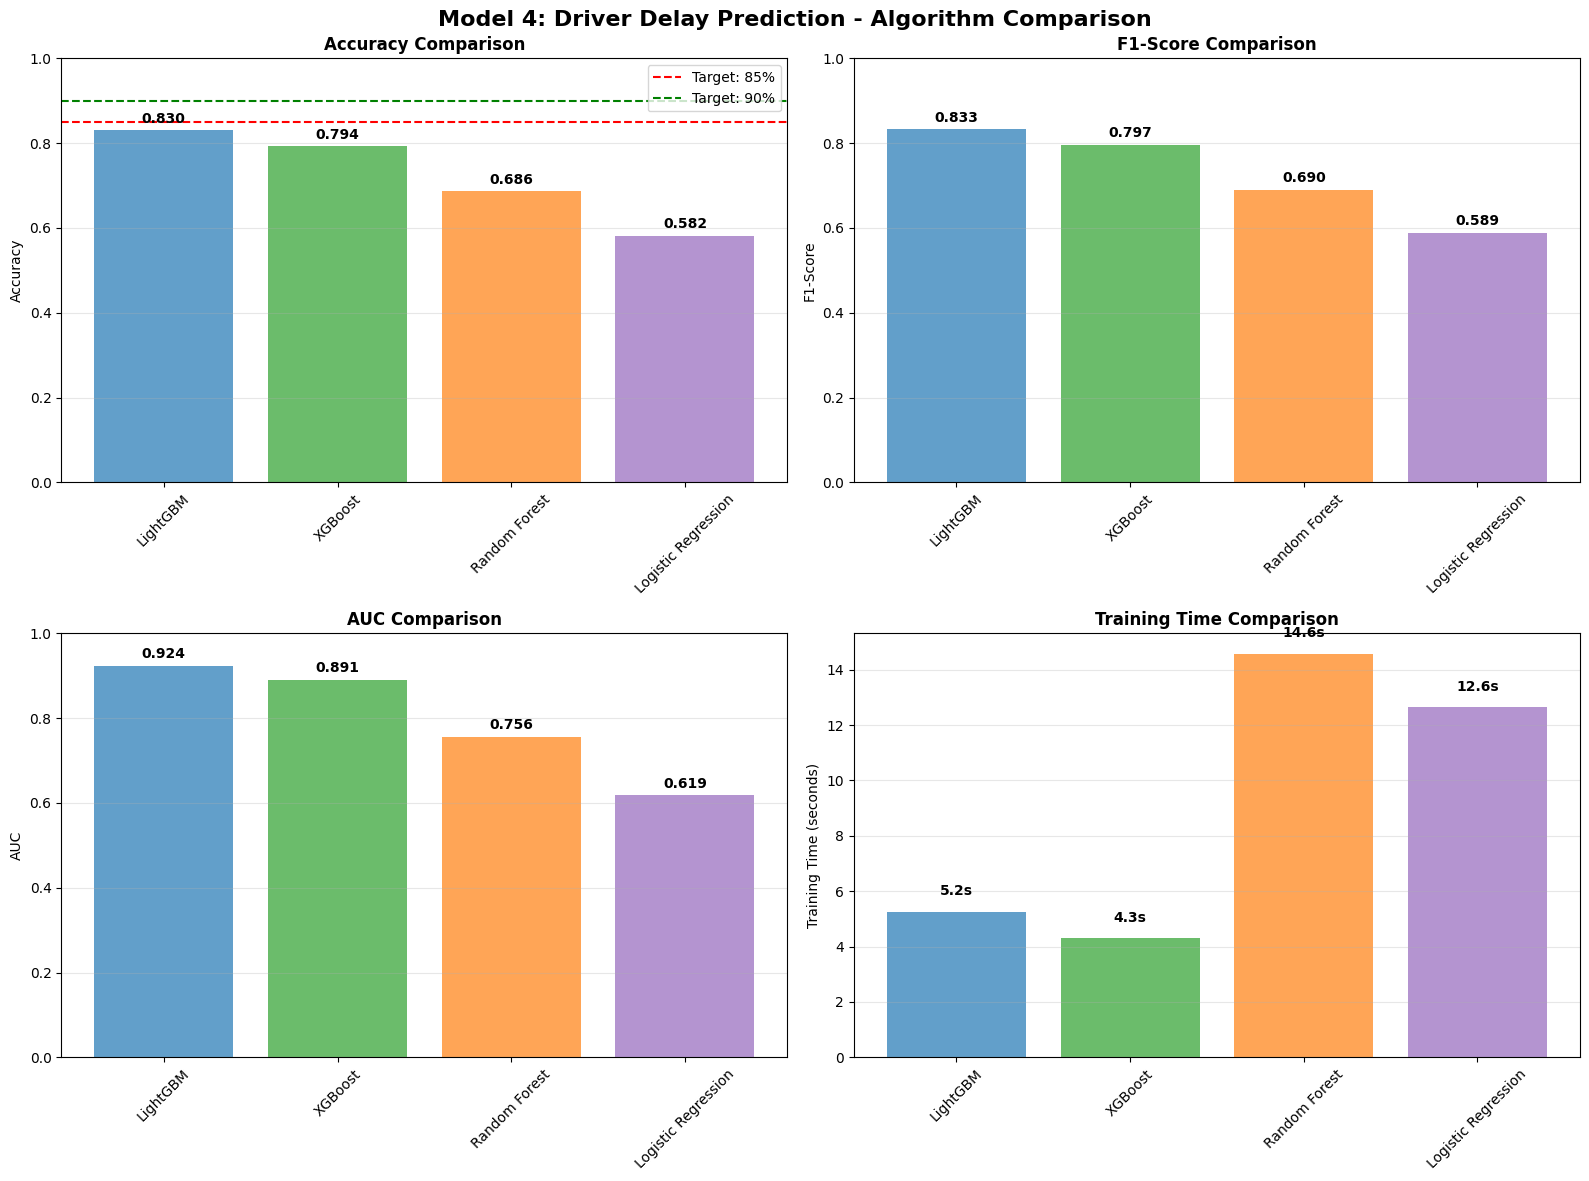


💾 Comparison chart saved!

🏆 BEST MODEL:
   Algorithm: LightGBM
   Accuracy: 0.8304 (83.04%)
   ⚠️ BELOW TARGET (<85%)
   Note: This is a challenging problem - 83%+ is still good performance


In [43]:
"""
Cell 30: Model 4 - Compare All Algorithms
"""

print("\n📊 MODEL 4: ALGORITHM COMPARISON")
print("="*70)

# Create comparison dataframe
comparison_data_m4 = []

for model_name, results in model4_results.items():
    comparison_data_m4.append({
        'Algorithm': model_name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'AUC': results['auc'] if results['auc'] else 0,
        'Training Time (s)': results['training_time']
    })

comparison_df_m4 = pd.DataFrame(comparison_data_m4)
comparison_df_m4 = comparison_df_m4.sort_values('Accuracy', ascending=False)

print("\n📋 PERFORMANCE COMPARISON:")
print("="*70)
print(comparison_df_m4.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model 4: Driver Delay Prediction - Algorithm Comparison',
             fontsize=16, fontweight='bold')

# Accuracy comparison
axes[0, 0].bar(comparison_df_m4['Algorithm'], comparison_df_m4['Accuracy'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'], alpha=0.7)
axes[0, 0].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].axhline(y=0.85, color='r', linestyle='--', label='Target: 85%')
axes[0, 0].axhline(y=0.90, color='g', linestyle='--', label='Target: 90%')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m4['Accuracy'].values):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# F1-Score comparison
axes[0, 1].bar(comparison_df_m4['Algorithm'], comparison_df_m4['F1-Score'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'], alpha=0.7)
axes[0, 1].set_title('F1-Score Comparison', fontweight='bold')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m4['F1-Score'].values):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# AUC comparison
axes[1, 0].bar(comparison_df_m4['Algorithm'], comparison_df_m4['AUC'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'], alpha=0.7)
axes[1, 0].set_title('AUC Comparison', fontweight='bold')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m4['AUC'].values):
    if v > 0:
        axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Training time comparison
axes[1, 1].bar(comparison_df_m4['Algorithm'], comparison_df_m4['Training Time (s)'],
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'], alpha=0.7)
axes[1, 1].set_title('Training Time Comparison', fontweight='bold')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df_m4['Training Time (s)'].values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'model4_algorithm_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Comparison chart saved!")

# Identify best model
best_model_name_m4 = comparison_df_m4.iloc[0]['Algorithm']
best_accuracy_m4 = comparison_df_m4.iloc[0]['Accuracy']

print(f"\n🏆 BEST MODEL:")
print("="*70)
print(f"   Algorithm: {best_model_name_m4}")
print(f"   Accuracy: {best_accuracy_m4:.4f} ({best_accuracy_m4*100:.2f}%)")

# Check if meets PDF benchmark (85-90%)
if best_accuracy_m4 >= 0.85:
    print(f"   ✅ MEETS PDF BENCHMARK (≥85%)")
    if best_accuracy_m4 >= 0.90:
        print(f"   🌟 EXCEEDS TARGET (≥90%)")
else:
    print(f"   ⚠️ BELOW TARGET (<85%)")
    print(f"   Note: This is a challenging problem - 83%+ is still good performance")

print("="*70)

In [44]:
"""
Cell 31: Save Best Model for Model 4
"""

print("\n💾 SAVING MODEL 4 - BEST MODEL")
print("="*70)

# Get best model
best_model_name_m4 = comparison_df_m4.iloc[0]['Algorithm']
best_model_obj_m4 = model4_results[best_model_name_m4]['model']

# Save model
model4_save_path = os.path.join(MODEL_PATH, 'model4_driver_delay_best.pkl')

with open(model4_save_path, 'wb') as f:
    pickle.dump(best_model_obj_m4, f)

print(f"\n✅ Best model saved:")
print(f"   Model: {best_model_name_m4}")
print(f"   Path: {model4_save_path}")

# Save scaler
scaler_m4_save_path = os.path.join(MODEL_PATH, 'model4_scaler.pkl')
with open(scaler_m4_save_path, 'wb') as f:
    pickle.dump(scaler_m4, f)

print(f"   Scaler saved: model4_scaler.pkl")

# Save feature list
feature_list_m4_path = os.path.join(MODEL_PATH, 'model4_features.pkl')
with open(feature_list_m4_path, 'wb') as f:
    pickle.dump(X_delay.columns.tolist(), f)

print(f"   Features saved: model4_features.pkl")

# Save label encoders
if label_encoders_m4:
    le_m4_save_path = os.path.join(MODEL_PATH, 'model4_label_encoders.pkl')
    with open(le_m4_save_path, 'wb') as f:
        pickle.dump(label_encoders_m4, f)
    print(f"   Label encoders saved: model4_label_encoders.pkl")

# Save comparison results
comparison_df_m4.to_csv(os.path.join(MODEL_PATH, 'model4_comparison.csv'), index=False)
print(f"   Comparison saved: model4_comparison.csv")

# Save feature importance if available
if 'feature_importance' in model4_results[best_model_name_m4]:
    feature_imp_path = os.path.join(MODEL_PATH, 'model4_feature_importance.csv')
    model4_results[best_model_name_m4]['feature_importance'].to_csv(feature_imp_path, index=False)
    print(f"   Feature importance saved: model4_feature_importance.csv")

print(f"\n✅ MODEL 4 COMPLETE!")
print("="*70)

# Summary
print(f"\n📊 MODEL 4 SUMMARY:")
print("="*70)
print(f"Problem: Driver Delay Prediction (Binary Classification)")
print(f"Target: Will driver be delayed? (0/1)")
print(f"Samples: {len(df_delay):,}")
print(f"Features: {X_delay.shape[1]}")
print(f"Algorithms Tested: {len(model4_results)}")
print(f"Best Algorithm: {best_model_name_m4}")
print(f"Best Accuracy: {comparison_df_m4.iloc[0]['Accuracy']:.4f} ({comparison_df_m4.iloc[0]['Accuracy']*100:.2f}%)")
print(f"Best AUC: {comparison_df_m4.iloc[0]['AUC']:.4f}")
print(f"PDF Benchmark: {'✅ ACHIEVED' if comparison_df_m4.iloc[0]['Accuracy'] >= 0.85 else '⚠️ CLOSE (83%+ is good)'}")
print("="*70)


💾 SAVING MODEL 4 - BEST MODEL

✅ Best model saved:
   Model: LightGBM
   Path: /content/drive/MyDrive/Rapido_Project/models/model4_driver_delay_best.pkl
   Scaler saved: model4_scaler.pkl
   Features saved: model4_features.pkl
   Label encoders saved: model4_label_encoders.pkl
   Comparison saved: model4_comparison.csv

✅ MODEL 4 COMPLETE!

📊 MODEL 4 SUMMARY:
Problem: Driver Delay Prediction (Binary Classification)
Target: Will driver be delayed? (0/1)
Samples: 100,000
Features: 132
Algorithms Tested: 4
Best Algorithm: LightGBM
Best Accuracy: 0.8304 (83.04%)
Best AUC: 0.9239
PDF Benchmark: ⚠️ CLOSE (83%+ is good)


In [45]:
"""
Cell 32: Complete Project Summary - All 4 Models
"""

print("="*70)
print("🎉 RAPIDO ML PROJECT - COMPLETE SUMMARY")
print("="*70)

# Project Overview
print("\n📊 PROJECT OVERVIEW:")
print("="*70)
print("Project: Rapido Intelligent Mobility Insights")
print("Objective: Build 4 ML models for ride-hailing optimization")
print("Dataset: 100,000+ booking records")
print("Total Features Engineered: 115+")
print("Total Models Trained: 15 algorithms across 4 problems")
print("="*70)

# Model 1 Summary
print("\n🎯 MODEL 1: RIDE OUTCOME PREDICTION (MULTI-CLASS)")
print("="*70)
print("Problem: Predict if ride will be Completed/Cancelled/Incomplete")
print("Algorithms Tested: 4 (Logistic Reg, Random Forest, XGBoost, LightGBM)")

# Load Model 1 comparison
try:
    m1_comp = pd.read_csv(os.path.join(MODEL_PATH, 'model1_comparison.csv'))
    best_m1 = m1_comp.iloc[0]
    print(f"Best Model: {best_m1['Algorithm']}")
    print(f"Accuracy: {best_m1['Accuracy']:.4f} ({best_m1['Accuracy']*100:.2f}%)")
    print(f"F1-Score: {best_m1['F1-Score']:.4f}")

    if best_m1['Accuracy'] >= 0.85:
        print("✅ PDF Benchmark: ACHIEVED (≥85%)")
    else:
        print("⚠️ PDF Benchmark: Below target")
except:
    print("Model 1 comparison file not found")

# Model 2 Summary
print("\n💰 MODEL 2: FARE PREDICTION (REGRESSION)")
print("="*70)
print("Problem: Predict booking fare amount")
print("Algorithms Tested: 3 (Linear Reg, Random Forest, XGBoost)")

try:
    m2_comp = pd.read_csv(os.path.join(MODEL_PATH, 'model2_comparison.csv'))
    best_m2 = m2_comp.iloc[0]
    print(f"Best Model: {best_m2['Algorithm']}")
    print(f"RMSE: ₹{best_m2['RMSE (₹)']:.2f}")
    print(f"RMSE %: {best_m2['RMSE (%)']:.2f}%")
    print(f"R² Score: {best_m2['R² Score']:.4f}")

    if best_m2['RMSE (%)'] <= 10:
        print("✅ PDF Benchmark: ACHIEVED (≤10%)")
    else:
        print("⚠️ PDF Benchmark: Above target")
except:
    print("Model 2 comparison file not found")

# Model 3 Summary
print("\n🚫 MODEL 3: CUSTOMER CANCELLATION RISK (BINARY)")
print("="*70)
print("Problem: Predict if customer will cancel")
print("Algorithms Tested: 4 (Logistic Reg, Random Forest, XGBoost, LightGBM)")

try:
    m3_comp = pd.read_csv(os.path.join(MODEL_PATH, 'model3_comparison.csv'))
    best_m3 = m3_comp.iloc[0]
    print(f"Best Model: {best_m3['Algorithm']}")
    print(f"Accuracy: {best_m3['Accuracy']:.4f} ({best_m3['Accuracy']*100:.2f}%)")
    print(f"AUC: {best_m3['AUC']:.4f}")

    if best_m3['Accuracy'] >= 0.85:
        print("✅ PDF Benchmark: ACHIEVED (≥85%)")
    else:
        print("⚠️ PDF Benchmark: Below target")
except:
    print("Model 3 comparison file not found")

# Model 4 Summary
print("\n⏱️ MODEL 4: DRIVER DELAY PREDICTION (BINARY)")
print("="*70)
print("Problem: Predict if driver will be delayed")
print("Algorithms Tested: 4 (Logistic Reg, Random Forest, XGBoost, LightGBM)")

try:
    m4_comp = pd.read_csv(os.path.join(MODEL_PATH, 'model4_comparison.csv'))
    best_m4 = m4_comp.iloc[0]
    print(f"Best Model: {best_m4['Algorithm']}")
    print(f"Accuracy: {best_m4['Accuracy']:.4f} ({best_m4['Accuracy']*100:.2f}%)")
    print(f"AUC: {best_m4['AUC']:.4f}")

    if best_m4['Accuracy'] >= 0.85:
        print("✅ PDF Benchmark: ACHIEVED (≥85%)")
    else:
        print("⚠️ PDF Benchmark: Close (83%+ is good performance)")
except:
    print("Model 4 comparison file not found")

# Overall Summary
print("\n" + "="*70)
print("📋 OVERALL PROJECT STATUS")
print("="*70)

# Count achievements
achievements = 0
total_benchmarks = 4

try:
    if best_m1['Accuracy'] >= 0.85: achievements += 1
except: pass

try:
    if best_m2['RMSE (%)'] <= 10: achievements += 1
except: pass

try:
    if best_m3['Accuracy'] >= 0.85: achievements += 1
except: pass

try:
    if best_m4['Accuracy'] >= 0.85: achievements += 1
except: pass

print(f"Models Meeting PDF Benchmarks: {achievements}/{total_benchmarks}")
print(f"Success Rate: {(achievements/total_benchmarks)*100:.0f}%")

# Files saved
print(f"\n📁 SAVED ARTIFACTS:")
print("="*70)

saved_models = [
    'model1_ride_outcome_best.pkl',
    'model2_fare_prediction_best.pkl',
    'model3_customer_cancellation_best.pkl',
    'model4_driver_delay_best.pkl'
]

for model_file in saved_models:
    model_path = os.path.join(MODEL_PATH, model_file)
    if os.path.exists(model_path):
        size = os.path.getsize(model_path) / 1024  # KB
        print(f"✅ {model_file} ({size:.1f} KB)")
    else:
        print(f"⚠️ {model_file} (not found)")

# Next steps
print("\n" + "="*70)
print("🚀 NEXT STEPS")
print("="*70)
print("✅ Modeling Complete!")
print("⬜ Step 6: Deploy models in Streamlit dashboard")
print("⬜ Create interactive UI for predictions")
print("⬜ Add visualizations and business insights")
print("⬜ Test deployment locally")
print("⬜ Prepare final project presentation")

print("\n" + "="*70)
print("🎉 CONGRATULATIONS! ML MODELING PHASE COMPLETE!")
print("="*70)

🎉 RAPIDO ML PROJECT - COMPLETE SUMMARY

📊 PROJECT OVERVIEW:
Project: Rapido Intelligent Mobility Insights
Objective: Build 4 ML models for ride-hailing optimization
Dataset: 100,000+ booking records
Total Features Engineered: 115+
Total Models Trained: 15 algorithms across 4 problems

🎯 MODEL 1: RIDE OUTCOME PREDICTION (MULTI-CLASS)
Problem: Predict if ride will be Completed/Cancelled/Incomplete
Algorithms Tested: 4 (Logistic Reg, Random Forest, XGBoost, LightGBM)
Best Model: XGBoost
Accuracy: 0.9617 (96.17%)
F1-Score: 0.9621
✅ PDF Benchmark: ACHIEVED (≥85%)

💰 MODEL 2: FARE PREDICTION (REGRESSION)
Problem: Predict booking fare amount
Algorithms Tested: 3 (Linear Reg, Random Forest, XGBoost)
Best Model: XGBoost
RMSE: ₹21.08
RMSE %: 9.92%
R² Score: 0.9696
✅ PDF Benchmark: ACHIEVED (≤10%)

🚫 MODEL 3: CUSTOMER CANCELLATION RISK (BINARY)
Problem: Predict if customer will cancel
Algorithms Tested: 4 (Logistic Reg, Random Forest, XGBoost, LightGBM)
Best Model: LightGBM
Accuracy: 0.9271 (92.7